# E28 · Imperfect detection: occupancy, N-mixture and capture-recapture models

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | (A) European crossbill detection/non-detection on 267 1-km² quadrats of the Swiss breeding bird survey, 2-3 visits a season, 1999-2007 (via `unmarked`); (B) repeated mallard counts on 239 Swiss survey routes (Kéry, Royle & Schmid 2005, via `unmarked`); (C) capture histories of 68 snowshoe hares over 6 trapping nights (Otis et al. 1978, Cormack 1989, via `Rcapture`) |
| **You will learn** | Why "not seen" is not "absent" · the site-occupancy model (MacKenzie et al. 2002) with the latent presence $z$ **summed out** in a `pm.CustomDist`, checked against `pymc_extras.marginalize` · how badly the naive "detected = present" model underestimates occupancy, and how it fakes year-to-year trends · finite-sample occupancy $P(z_i = 1 \mid y)$ recovered in NumPy · detection-history posterior predictive checks and site-level LOO · when occupancy and detection become **confounded** (few visits, prior sensitivity) · the **N-mixture** model (Royle 2004) with $N$ summed to a bound $K$, checking $K$ · the $N$-$p$ trade-off and the Poisson vs negative-binomial choice · closed-population **capture-recapture** by **data augmentation** (models $M_0$, $M_t$, $M_h$) and the famous non-identifiability of $N$ under heterogeneity (Link 2003) |

Ecologists rarely see what they count. A bird that sits quietly in a spruce while the
surveyor walks past is recorded as a zero; a hare that avoids the trap on three of six
nights is caught three times, not six. Every field survey therefore observes the product of
two processes: an **ecological** one (is the species here? how many animals are there?) and
an **observation** one (given that it is here, did we detect it?). A model that ignores the
second one estimates "how often we saw it", not "where it lives", and the difference is not a
small correction: it moves with anything that changes detectability - weather, observer,
habitat, effort.

The fix is repeated visits. If a site is visited three times and the bird is found on one
visit, we have learned both that it is there and that it is easy to miss; sites that are
never detected are then a *mixture* of empty sites and occupied sites where we were unlucky,
in proportions the model can estimate. The latent quantities are discrete - presence $z_i \in
\{0, 1\}$ in part A, abundance $N_i \in \{0, 1, 2, \dots\}$ in parts B and C - and, as in
E04 (one changepoint) and E24 (a chain of hidden states), we **sum them out** so that NUTS
sees a smooth likelihood of the continuous parameters, and reconstruct them afterwards from
the posterior.

In [1]:
import gzip
import logging
import lzma
import struct
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from pymc_extras.marginal import marginalize, recover
from scipy.special import expit, gammaln, logsumexp

from pymc_challenges import data

warnings.filterwarnings("ignore", message="Numba will use object mode")  # our NumPy `random=` functions
logging.getLogger("pymc").setLevel(logging.WARNING)  # ~35 fits: the helper prints one line per fit

RANDOM_SEED = 2002
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8e5bd0"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def fit(model, label, **kw):
    """One place for the sampler settings (nutpie, 4 chains x 1000 draws); prints a diagnostic line."""
    kw.setdefault("target_accept", 0.9)
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kw)
    post = idata.posterior
    free = [v.name for v in model.free_RVs]
    rhat = max(float(az.rhat(post[v]).max()) for v in free)
    ess = min(float(az.ess(post[v]).min()) for v in free)
    print(f"  {label:<28s} {time.time() - t0:5.1f} s | divergences {int(idata.sample_stats['diverging'].sum())}"
          f" | max r_hat {rhat:.3f} | min ESS {ess:.0f}")
    return idata


def draws(idata, var, n=None):
    """Posterior draws of `var` as a NumPy array with one leading 'sample' axis (optionally thinned to n)."""
    x = idata.posterior[var].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()
    return x if n is None else x[:: max(1, len(x) // n)][:n]

PyMC 6.3.2, ArviZ 1.3.0


## Part A · Where does the crossbill live? Site occupancy

## 1 · Data: 267 quadrats, 2-3 visits a season

The Swiss breeding bird survey (*Monitoring Häufige Brutvögel*, MHB) sends volunteers along a
fixed route through each of 267 one-square-kilometre quadrats, two or three times every
breeding season. For the European crossbill - a conifer-seed specialist that is easy to
overlook when it is not calling - we have, for 1999-2007, whether it was detected on each
visit, the day of the season of each visit, and two quadrat properties: elevation and forest
cover. The R package `unmarked` ships the data as an R serialisation (`.rda`, xz-compressed);
as in E23 and E24 we read R's format directly with a small reader.

In [2]:
def read_rdata(path):
    """Minimal reader for R's XDR serialisation (.rda/.RData): named lists, vectors, strings (see E23/E24)."""
    raw = open(path, "rb").read()
    buf = lzma.decompress(raw) if raw[:2] == b"\xfd7" else gzip.decompress(raw)  # xz or gzip
    assert buf[:7] in (b"RDX2\nX\n", b"RDX3\nX\n"), "not an XDR R data file"
    pos, refs = 7, []

    def i32():
        nonlocal pos
        pos += 4
        return struct.unpack(">i", buf[pos - 4:pos])[0]

    def item():
        nonlocal pos
        flags = i32()
        kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
        if kind == 254:                                     # NULL
            return None
        if kind == 255:                                     # reference to an earlier symbol
            return refs[(flags >> 8) - 1]
        if kind == 1:                                       # symbol
            refs.append(item())
            return refs[-1]
        if kind == 9:                                       # string
            n = i32()
            pos += max(n, 0)
            return None if n == -1 else buf[pos - n:pos].decode()
        if kind == 2:                                       # pairlist -> dict
            out = {}
            while kind == 2:
                _ = item() if has_attr else None
                tag = item() if has_tag else None
                out[tag] = item()
                flags = i32()
                kind, has_attr, has_tag = flags & 0xFF, flags & (1 << 9), flags & (1 << 10)
            return out
        n = i32()
        if kind in (10, 13):                                # logical / integer
            value, pos = np.frombuffer(buf, ">i4", n, pos).astype(int), pos + 4 * n
        elif kind == 14:                                    # double
            value, pos = np.frombuffer(buf, ">f8", n, pos).astype(float), pos + 8 * n
        elif kind in (16, 19):                              # character vector / list
            value = [item() for _ in range(n)]
        else:
            raise NotImplementedError(f"R type {kind}")
        attrs = item() if has_attr else None
        if kind == 19 and attrs and "names" in attrs:
            value = dict(zip(attrs["names"], value))
        return value

    version = i32()
    pos += 8
    if version == 3:
        pos += 4 + struct.unpack(">i", buf[pos:pos + 4])[0]
    return item()


data.describe("crossbill")
cb = pd.DataFrame(read_rdata(data.path("crossbill"))["crossbill"]).astype(float)
cb = cb.mask(cb == -2147483648)          # R's integer NA
YEARS = [f"{y:02d}" for y in (99, 0, 1, 2, 3, 4, 5, 6, 7)]


def season(yy):
    """Detections Y, visit dates D and the 'visit happened' mask S for one season (sites never visited dropped)."""
    Y = cb[[f"det{yy}{k}" for k in (1, 2, 3)]].to_numpy()
    D = cb[[f"date{yy}{k}" for k in (1, 2, 3)]].to_numpy()
    S = ~np.isnan(Y) & ~np.isnan(D)
    keep = S.any(axis=1)
    return keep, np.where(S, Y, 0).astype(int)[keep], np.where(S, D, 0.0)[keep], S[keep]


rows = []
for yy in YEARS:
    keep, Y, D, S = season(yy)
    rows.append({"season": 2000 + int(yy) if yy != "99" else 1999, "sites visited": keep.sum(),
                 "with 3 visits": S.all(1).sum(), "detected at least once": (Y.sum(1) > 0).sum(),
                 "naive occupancy": (Y.sum(1) > 0).mean().round(3),
                 "detections per visit": Y.sum() / S.sum()})
pd.DataFrame(rows).set_index("season").round(3)

crossbill: 267 1-km2 quadrats surveyed 2-3 times a season in 1999-2007: detection/non-detection det<yy><k>, day of season date<yy><k>, elevation ele (m), forest cover (%). Not a table: an R serialisation (xz XDR), NA = -2147483648 - parse data.path() (see E28).
  source: Swiss breeding bird survey MHB (Schmid, Zbinden & Keller 2004, Swiss Ornithological Institute), European crossbill Loxia curvirostra, as shipped with the R package `unmarked` (Fiske & Chandler 2011); analysed in Kery & Royle, Applied Hierarchical Modeling in Ecology (2016).
  url:    https://raw.githubusercontent.com/cran/unmarked/master/data/crossbill.rda


,sites visited,with 3 visits,detected at least once,naive occupancy,detections per visit
season,,,,,
1999,245,201,63,0.257,0.133
2000,265,217,92,0.347,0.245
2001,260,215,57,0.219,0.147
2002,262,216,85,0.324,0.201
2003,264,217,105,0.398,0.264
2004,264,217,82,0.311,0.207
2005,266,218,92,0.346,0.256
2006,264,214,70,0.265,0.150
2007,265,217,93,0.351,0.236


About a sixth of the quadrats - mostly the high alpine ones - get only two visits. The naive
occupancy (share of quadrats where the crossbill was seen at least once) jumps around between
0.22 and 0.40 from year to year. Is that the population, or the observers? We start with the
1999 season, where the bird was detected on only one visit in eight.

In [3]:
keep, Y, D, S = season("99")
site = cb[keep].reset_index(drop=True)
ELE = (site.ele.to_numpy() - 1200) / 600           # standardised with round constants, so the
FOREST = (site.forest.to_numpy() - 35) / 28        # same scale is used in every season
DATE = np.where(S, (D - 55) / 20, 0.0)             # day of season: 0 = 25 April-ish, 1 unit = 20 days
n_site = len(site)
hist = pd.Series(["".join(map(str, r)) if s.all() else "".join(map(str, r[:2])) + "-" for r, s in zip(Y, S)])
print(f"1999: {n_site} quadrats, {S.sum()} visits, {Y.sum()} detections on "
      f"{(Y.sum(1) > 0).sum()} quadrats")
hist.value_counts().rename("quadrats").to_frame().T

1999: 245 quadrats, 691 visits, 92 detections on 63 quadrats


,000,00-,001,100,011,010,111,10-,110,101
quadrats,141,41,19,10,10,10,8,3,2,1


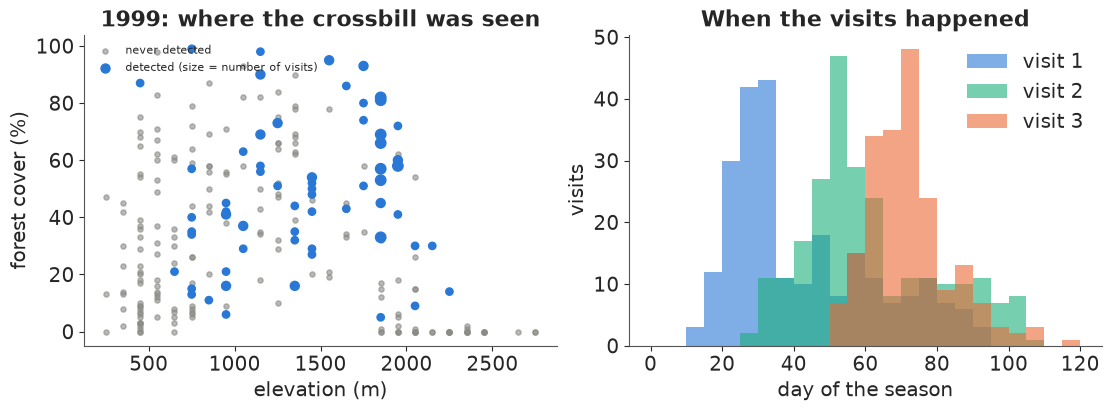

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
det = Y.sum(1) > 0
axes[0].scatter(site.ele[~det], site.forest[~det], s=14, color=GREY, alpha=0.6, label="never detected")
axes[0].scatter(site.ele[det], site.forest[det], s=14 + 14 * Y.sum(1)[det], color=BLUE,
                label="detected (size = number of visits)")
axes[0].set(xlabel="elevation (m)", ylabel="forest cover (%)", title="1999: where the crossbill was seen")
axes[0].legend(loc="upper left", fontsize=8)
for k, c in zip(range(3), [BLUE, AQUA, ORANGE]):
    ok = S[:, k]
    axes[1].hist(D[ok, k], bins=np.arange(0, 125, 5), color=c, alpha=0.6, label=f"visit {k + 1}")
axes[1].set(xlabel="day of the season", ylabel="visits", title="When the visits happened")
axes[1].legend();

The detections sit in the middle of the elevation range (the montane conifer belt, roughly
1000-2000 m) and mostly in forested quadrats. The three visits are spread through the
season, so any seasonal change in detectability (the crossbill breeds early and becomes
quieter, or louder, as the season goes on) can be separated from the site properties.

## 2 · The occupancy model, and why the latent presence can be summed out

For quadrat $i$ with visits $j = 1, \dots, J_i$:

$$z_i \sim \text{Bernoulli}(\psi_i), \qquad y_{ij} \mid z_i \sim \text{Bernoulli}(z_i\, p_{ij}),$$
$$\text{logit}\, \psi_i = \alpha_0 + \alpha_1\, \text{ele}_i + \alpha_2\, \text{ele}_i^2 + \alpha_3\, \text{forest}_i, \qquad
  \text{logit}\, p_{ij} = \beta_0 + \beta_1\, \text{date}_{ij} + \beta_2\, \text{date}_{ij}^2 .$$

$\psi$ is **occupancy** (the ecological quantity), $p$ is **detection given presence** (the
observation quantity). Summing over $z_i \in \{0, 1\}$ gives the likelihood of a whole
detection history:

$$P(y_{i\cdot}) = \psi_i \prod_j p_{ij}^{y_{ij}} (1 - p_{ij})^{1 - y_{ij}} \;+\; (1 - \psi_i)\, \mathbb{1}[y_{i\cdot} = 0].$$

A quadrat with a detection is certainly occupied (only the first term survives); an all-zero
history is a mixture of "occupied but missed every time" and "empty". This is a two-term
`logsumexp`, which we write as the `logp` of a `pm.CustomDist` over the whole history (so the
log-likelihood - and LOO - is per *quadrat*, the natural unit). A `random` function in NumPy
makes prior and posterior predictive sampling work too. Visits that did not happen are
handled by a 0/1 mask: they simply contribute nothing.

In [5]:
def occupancy_logp(y, psi, p, mask):
    ll_seen = pt.sum(mask * (y * pt.log(p) + (1 - y) * pt.log1p(-p)), axis=-1)   # log P(history | z = 1)
    detected = pt.gt(pt.sum(mask * y, axis=-1), 0)
    return pt.switch(detected, pt.log(psi) + ll_seen,
                     pt.logaddexp(pt.log(psi) + ll_seen, pt.log1p(-psi)))


def occupancy_random(psi, p, mask, rng=None, size=None):
    z = rng.binomial(1, psi)
    return rng.binomial(1, z[..., None] * p) * mask


PSI_COVS = ["ele", "ele²", "forest"]


def occupancy_model(Y, S, ele, forest, date, p_covs=("date", "date²"), b0_prior=(0.0, 1.5), name=""):
    X_psi = np.c_[ele, ele**2, forest]
    cols = {"date": date, "date²": date**2, "ele": ele[:, None] + 0 * date}
    X_p = np.stack([cols[c] for c in p_covs], -1) if p_covs else None
    coords = {"site": np.arange(len(Y)), "visit": [1, 2, 3], "psi_cov": PSI_COVS, "p_cov": list(p_covs)}
    with pm.Model(coords=coords, name=name) as m:
        a0 = pm.Normal("a0", 0.0, 1.5)
        a = pm.Normal("a", 0.0, 1.0, dims="psi_cov")
        b0 = pm.Normal("b0", *b0_prior)
        eta_p = b0 + 0 * date
        if p_covs:
            b = pm.Normal("b", 0.0, 1.0, dims="p_cov")
            eta_p = eta_p + pt.tensordot(X_p, b, axes=[[-1], [0]])
        psi = pm.Deterministic("psi", pm.math.invlogit(a0 + X_psi @ a), dims="site")
        p = pm.math.invlogit(eta_p)
        pm.CustomDist("y", psi, p, S.astype(float), logp=occupancy_logp, random=occupancy_random,
                      signature="(),(v),(v)->(v)", observed=Y, dims=("site", "visit"))
    return m


occ = occupancy_model(Y, S, ELE, FOREST, DATE)
print(occ.str_repr())

 a0 ~ Normal(0, 1.5)
  a ~ Normal(0, 1)
 b0 ~ Normal(0, 1.5)
  b ~ Normal(0, 1)
psi = Deterministic(f(a0, a))
  y ~ CustomDist_y(psi, f(b0, b), <constant>)


**Priors.** On the logit scale, Normal(0, 1.5) for the intercepts puts most mass between 5%
and 95% occupancy/detection without piling up at 0 and 1; the slopes are per standardised unit
(600 m of elevation, 28 points of forest cover, 20 days), and Normal(0, 1) allows a change of a
few odds-ratio units across the range - generous but not absurd. The prior predictive check
asks the only data-level question that matters here: how many quadrats would we expect to see
the bird on?

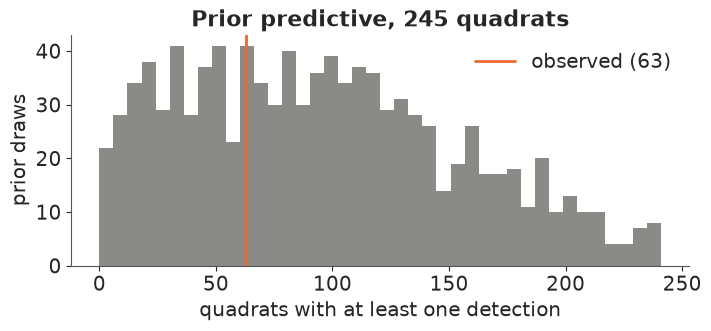

In [6]:
with occ:
    prior = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
n_det_prior = (prior.prior_predictive["y"].sum("visit") > 0).sum("site").to_numpy().ravel()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(n_det_prior, bins=40, color=GREY)
ax.axvline(det.sum(), color=ORANGE, lw=2, label=f"observed ({det.sum()})")
ax.set(xlabel="quadrats with at least one detection", ylabel="prior draws",
       title=f"Prior predictive, {n_site} quadrats")
ax.legend();

The prior allows anything from a handful of quadrats to nearly all of them, with the
observed 63 comfortably inside: the prior is weakly informative, not a guess of the answer.

## 3 · Fit, and what the naive model gets wrong

The naive alternative - the model used whenever detection is ignored - treats "detected at
least once" as "present": a logistic regression of $\max_j y_{ij}$ on the same covariates.
Its $\psi$ is really $\psi \times P(\text{detected at least once} \mid \text{present})$.

In [7]:
idata_occ = fit(occ, "occupancy, 1999")
print("warm-up steps:", idata_occ.posterior.attrs.get("tuning_steps"))
az.summary(idata_occ, var_names=["a0", "a", "b0", "b"], ci_kind="hdi", ci_prob=0.94, round_to=2)

  occupancy, 1999                2.0 s | divergences 0 | max r_hat 1.002 | min ESS 1309
warm-up steps: 400


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a0,0.46,0.50,-0.39,1.43,1308.88,1394.05,1.0,0.01,0.01
a[ele],1.04,0.27,0.51,1.51,2780.16,2597.32,1.0,0.01,0.00
a[ele²],-1.11,0.32,-1.69,-0.50,1587.44,1628.66,1.0,0.01,0.01
a[forest],0.69,0.28,0.17,1.21,3500.84,2662.65,1.0,0.00,0.01
b0,-0.78,0.26,-1.26,-0.29,1637.20,2273.27,1.0,0.01,0.00
b[date],0.55,0.17,0.23,0.85,3060.33,2809.13,1.0,0.00,0.00
b[date²],-0.06,0.12,-0.28,0.17,2484.22,2567.56,1.0,0.00,0.00


In [8]:
with pm.Model(coords={"psi_cov": PSI_COVS}) as naive:
    a0 = pm.Normal("a0", 0.0, 1.5)
    a = pm.Normal("a", 0.0, 1.0, dims="psi_cov")
    psi_naive = pm.Deterministic("psi", pm.math.invlogit(a0 + np.c_[ELE, ELE**2, FOREST] @ a))
    pm.Bernoulli("detected", psi_naive, observed=det.astype(int))
idata_naive = fit(naive, "naive logistic, 1999")

psi_bar = draws(idata_occ, "psi").mean(1)            # average occupancy over the 245 quadrats
psi_bar_naive = draws(idata_naive, "psi").mean(1)
for lab, x in [("naive (detected = present)", psi_bar_naive), ("occupancy model", psi_bar)]:
    print(f"{lab:<28s} mean occupancy {x.mean():.3f}  94% HDI {az.hdi(x, prob=0.94).round(3)}")
print(f"raw share detected: {det.mean():.3f};  occupancy / naive = {np.mean(psi_bar / psi_bar_naive):.2f}")

  naive logistic, 1999           0.6 s | divergences 0 | max r_hat 1.002 | min ESS 2107
naive (detected = present)   mean occupancy 0.259  94% HDI [0.215 0.308]
occupancy model              mean occupancy 0.386  94% HDI [0.29  0.486]
raw share detected: 0.257;  occupancy / naive = 1.51


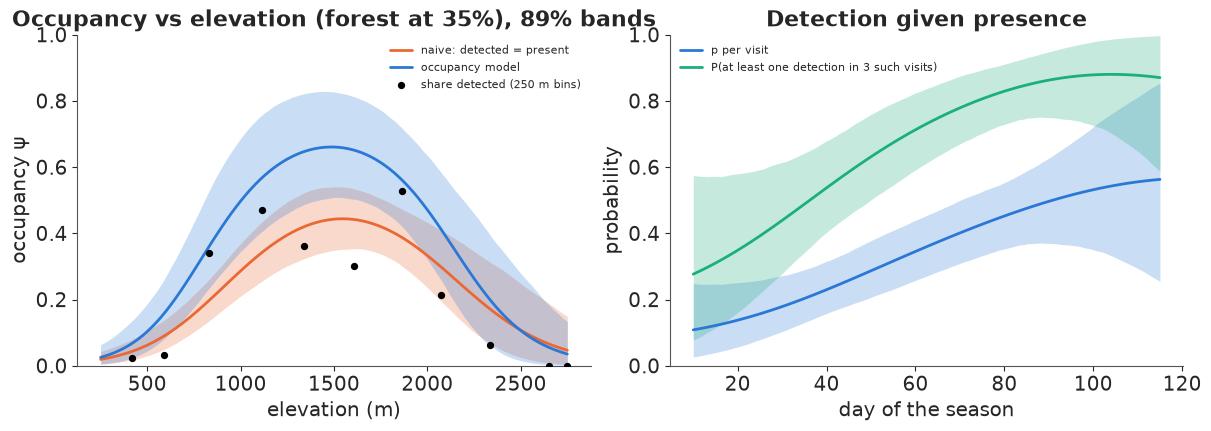

In [9]:
ele_grid = np.linspace(250, 2750, 101)
eg = (ele_grid - 1200) / 600
date_grid = np.linspace(10, 115, 100)
dg = (date_grid - 55) / 20


def band(ax, x, samples, color, label):
    lo, hi = np.quantile(samples, [0.055, 0.945], axis=0)
    ax.fill_between(x, lo, hi, color=color, alpha=0.25, lw=0)
    ax.plot(x, samples.mean(0), color=color, lw=2, label=label)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for idata_, c, lab in [(idata_naive, ORANGE, "naive: detected = present"), (idata_occ, BLUE, "occupancy model")]:
    a0_, a_ = draws(idata_, "a0"), draws(idata_, "a")
    band(axes[0], ele_grid, expit(a0_[:, None] + a_[:, [0]] * eg + a_[:, [1]] * eg**2), c, lab)
bins = np.arange(250, 2800, 250)
idx = np.digitize(site.ele, bins)
axes[0].scatter([site.ele[idx == k].mean() for k in np.unique(idx)], [det[idx == k].mean() for k in np.unique(idx)],
                color="k", s=18, zorder=3, label="share detected (250 m bins)")
axes[0].set(xlabel="elevation (m)", ylabel="occupancy ψ", ylim=(0, 1),
            title="Occupancy vs elevation (forest at 35%), 89% bands")
axes[0].legend(fontsize=8)
b0_, b_ = draws(idata_occ, "b0"), draws(idata_occ, "b")
p_date = expit(b0_[:, None] + b_[:, [0]] * dg + b_[:, [1]] * dg**2)
band(axes[1], date_grid, p_date, BLUE, "p per visit")
band(axes[1], date_grid, 1 - (1 - p_date) ** 3, AQUA, "P(at least one detection in 3 such visits)")
axes[1].set(xlabel="day of the season", ylabel="probability", ylim=(0, 1),
            title="Detection given presence")
axes[1].legend(fontsize=8);

Both fits are clean (no divergences, r_hat at most 1.004). Detection is poor in 1999: at
day 55 a present crossbill is found on a visit with probability about 0.3, rising through the
season (the date slope is clearly positive, the curvature is not needed) from about 0.1 at
the first visits to about 0.5 at the last ones. Three mid-season visits find an occupied quadrat only
about two times in three, so roughly a third of the occupied quadrats should show 000.

The occupancy model accordingly puts mean occupancy at **0.39** (94% HDI 0.29-0.49), against
**0.26** for the naive model - the naive estimate is about a third too low, and its interval
(0.22-0.31) barely overlaps the corrected one: it is *precisely wrong*. The elevation curve
shows where the difference lives: in the montane belt around 1500 m the naive model says 0.44
and the occupancy model 0.66; at the extremes, where the bird is absent either way, the two
agree. The naive curve follows the binned share of detected quadrats (black dots) closely,
which is exactly the problem: it models what the observers saw. Forest cover raises occupancy
in both models.

### Cross-check: the same model through `pymc_extras.marginalize`

The hand-written `logp` is the whole point of this notebook, but it is also easy to get
wrong. `pymc_extras` can derive the same marginal likelihood automatically from the model
written *with* the discrete $z$ (E04 and E24 did the same). One gotcha: it cannot marginalise
through advanced indexing like `z[site_of_visit]` (it raises "Partial slicing or advanced
integer indexing ... not supported"), so the observations stay a (site x visit) matrix and
the missed visits get $p = 0$ and $y = 0$, which contributes exactly $\log 1 = 0$. `recover`
then samples $z$ from its conditional posterior.

In [10]:
with pm.Model(coords={"site": np.arange(n_site), "psi_cov": PSI_COVS}) as occ_z:
    a0 = pm.Normal("a0", 0.0, 1.5)
    a = pm.Normal("a", 0.0, 1.0, dims="psi_cov")
    b0 = pm.Normal("b0", 0.0, 1.5)
    b = pm.Normal("b", 0.0, 1.0, shape=2)
    psi = pm.math.invlogit(a0 + np.c_[ELE, ELE**2, FOREST] @ a)
    p = pm.math.invlogit(b0 + b[0] * DATE + b[1] * DATE**2) * S          # p = 0 on visits that did not happen
    z = pm.Bernoulli("z", psi, dims="site")
    pm.Bernoulli("y", z[:, None] * p, observed=Y)
occ_marg = marginalize(occ_z, ["z"])
idata_marg = fit(occ_marg, "same model via marginalize")
with occ_marg:
    idata_rec = recover(idata_marg.isel(draw=slice(None, None, 4)), var_names=["z"])
cmp = pd.DataFrame({v: [f"{float(idata_occ.posterior[v].mean()):.3f}", f"{float(idata_marg.posterior[v].mean()):.3f}"]
                    for v in ["a0", "b0"]}, index=["CustomDist", "marginalize"])
cmp["alpha (ele, ele², forest)"] = [draws(idata_occ, "a").mean(0).round(2), draws(idata_marg, "a").mean(0).round(2)]
cmp

  same model via marginalize     1.6 s | divergences 0 | max r_hat 1.004 | min ESS 1201


,a0,b0,"alpha (ele, ele², forest)"
CustomDist,0.463,-0.784,"[1.04, -1.11, 0.69]"
marginalize,0.490,-0.797,"[1.05, -1.12, 0.7]"


Same posterior, up to Monte Carlo error. We keep `idata_rec` for the next section.

## 4 · Which quadrats are occupied? Finite-sample occupancy

$\psi_i$ is a property of the *landscape*: the probability that a quadrat like $i$ is occupied.
For the 245 quadrats actually surveyed we can say more, because we have their data. For a
quadrat with a detection, $z_i = 1$. For one with an all-zero history, Bayes' rule gives

$$P(z_i = 1 \mid y_{i\cdot} = 0) = \frac{\psi_i \prod_j (1 - p_{ij})}{\psi_i \prod_j (1 - p_{ij}) + 1 - \psi_i},$$

which is one line of NumPy per posterior draw. Summing $z_i$ over quadrats gives the
**number of occupied quadrats** in 1999 - a finite-sample quantity that the naive count (63)
can only undershoot.

In [11]:
psi_d = draws(idata_occ, "psi", 1000)                                   # (draw, site)
b0_d, b_d = draws(idata_occ, "b0", 1000), draws(idata_occ, "b", 1000)
p_d = expit(b0_d[:, None, None] + b_d[:, None, None, 0] * DATE + b_d[:, None, None, 1] * DATE**2)
miss_all = np.prod(np.where(S, 1 - p_d, 1.0), axis=2)                   # P(all visits missed | z = 1)
q = np.where(det, 1.0, psi_d * miss_all / (psi_d * miss_all + 1 - psi_d))   # P(z_i = 1 | y)
z_draws = rng.binomial(1, q)
n_occ = z_draws.sum(1)
q_rec = idata_rec.posterior["z"].mean(("chain", "draw")).to_numpy()
print(f"P(z=1|y) for never-detected quadrats: NumPy vs recover() max abs difference "
      f"{np.abs(q.mean(0) - q_rec)[~det].max():.3f} (recover uses 1000 draws of z)")
print(f"occupied quadrats in 1999: {n_occ.mean():.1f}, 94% HDI {az.hdi(n_occ, prob=0.94)} "
      f"(detected on {det.sum()}; landscape expectation sum(psi) = {psi_d.sum(1).mean():.1f})")

P(z=1|y) for never-detected quadrats: NumPy vs recover() max abs difference 0.049 (recover uses 1000 draws of z)
occupied quadrats in 1999: 94.6, 94% HDI [ 75. 116.] (detected on 63; landscape expectation sum(psi) = 94.0)


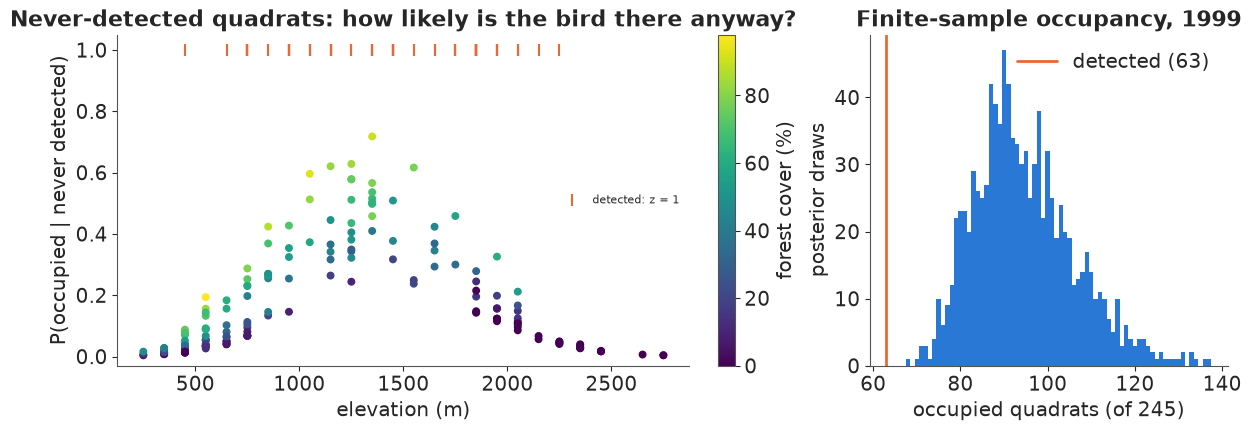

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
sc = axes[0].scatter(site.ele[~det], q.mean(0)[~det], c=site.forest[~det], cmap="viridis", s=22)
axes[0].scatter(site.ele[det], np.ones(det.sum()), color=ORANGE, marker="|", s=80, label="detected: z = 1")
fig.colorbar(sc, ax=axes[0], label="forest cover (%)")
axes[0].set(xlabel="elevation (m)", ylabel="P(occupied | never detected)", ylim=(-0.03, 1.05),
            title="Never-detected quadrats: how likely is the bird there anyway?")
axes[0].legend(loc="center right", fontsize=8)
axes[1].hist(n_occ, bins=np.arange(n_occ.min() - 0.5, n_occ.max() + 1.5), color=BLUE)
axes[1].axvline(det.sum(), color=ORANGE, lw=2, label=f"detected ({det.sum()})")
axes[1].set(xlabel="occupied quadrats (of 245)", ylabel="posterior draws", title="Finite-sample occupancy, 1999")
axes[1].legend();

The NumPy formula and `recover()` agree to about 0.05 at worst - the Monte Carlo error of
averaging 1000 sampled 0/1 values of $z$ (sd up to 0.016 per quadrat; 0.05 is the worst of 182). Of the 182 never-detected quadrats, those at 1000-1500 m with dense forest have a
probability of 0.5-0.7 of holding crossbills anyway; low-lying and alpine quadrats are almost
certainly empty. Summed up, about **95 quadrats (94% HDI 75-116) were occupied in 1999**, against
63 where the bird was actually seen. Note that the finite-sample total (95) is almost the same
as $\sum_i \psi_i$ (94) but it is conditioned on the data: the 63 detected quadrats contribute
exactly 1 each instead of their $\psi_i$.

## 5 · Checking the model: detection histories and site-level LOO

The data are detection histories, so the posterior predictive check compares **history
frequencies**: for the quadrats with three visits, how many show 000, 001, ..., 111? A model
that gets $p$ wrong mispredicts the ratio of single to repeated detections; one that gets
$\psi$ wrong mispredicts the number of 000s.

000 histories: observed 141, predicted 143.5 [128, 158]


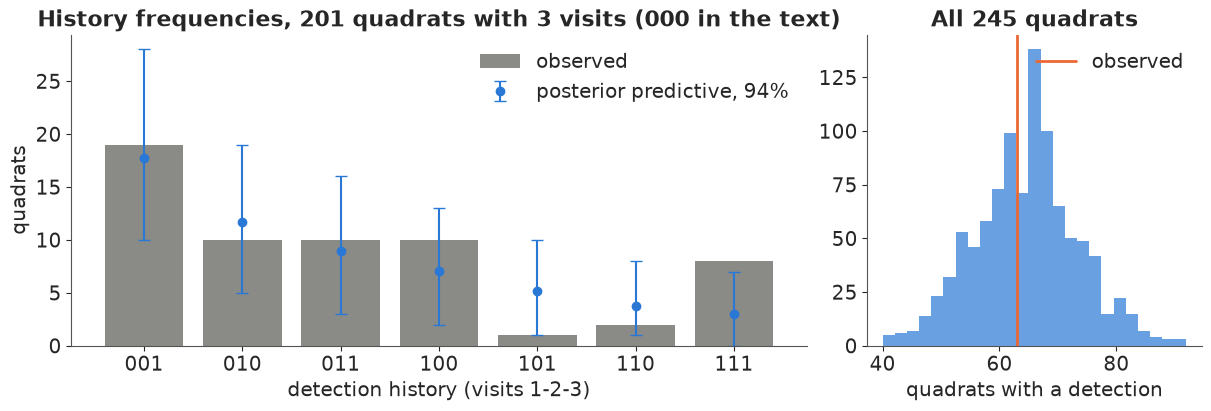

In [13]:
with occ:
    ppc = pm.sample_posterior_predictive(idata_occ.isel(draw=slice(None, None, 4)), random_seed=RANDOM_SEED,
                                         progressbar=False)
yrep = ppc.posterior_predictive["y"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy().astype(int)
three = S.all(1)
codes = ["".join(c) for c in np.array(np.meshgrid(*[["0", "1"]] * 3, indexing="ij")).reshape(3, -1).T]
w = np.array([4, 2, 1])
obs_f = np.bincount(Y[three] @ w, minlength=8)
rep_f = np.stack([np.bincount(r @ w, minlength=8) for r in yrep[:, three]])
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2.2, 1]})
lo, hi = np.quantile(rep_f, [0.03, 0.97], axis=0)
axes[0].bar(range(1, 8), obs_f[1:], color=GREY, label="observed")
axes[0].errorbar(range(1, 8), rep_f.mean(0)[1:], yerr=[rep_f.mean(0)[1:] - lo[1:], hi[1:] - rep_f.mean(0)[1:]],
                 fmt="o", color=BLUE, capsize=4, label="posterior predictive, 94%")
axes[0].set_xticks(range(1, 8), codes[1:])
axes[0].set(xlabel="detection history (visits 1-2-3)", ylabel="quadrats",
            title=f"History frequencies, {three.sum()} quadrats with 3 visits (000 in the text)")
axes[0].legend()
n_rep = (yrep.sum(2) > 0).sum(1)
axes[1].hist(n_rep, bins=25, color=BLUE, alpha=0.7)
axes[1].axvline(det.sum(), color=ORANGE, lw=2, label="observed")
axes[1].set(xlabel="quadrats with a detection", title="All 245 quadrats")
axes[1].legend()
print(f"000 histories: observed {obs_f[0]}, predicted {rep_f[:, 0].mean():.1f} "
      f"[{lo[0]:.0f}, {hi[0]:.0f}]");

The total number of 000 histories and the number of quadrats with a detection are reproduced
well, as are most individual histories. The one misfit is at the top: **eight quadrats were
detected on all three visits**, and the model expects about three (94% interval 0-7), while it
expects more 101/110 than were seen. Too many "always detected" quadrats is the classic symptom
of **detection heterogeneity between sites**: in some quadrats the crossbill is easy to find
(many birds, calling), in others hard, and a single $p$ averages the two.

**Does detection depend on the date - or on elevation?** Site-level LOO (one quadrat's
whole history left out at a time) compares detection sub-models on the same data. We add a
variant in which detection also changes with elevation (high, open quadrats could be easier -
or the birds there sparser and quieter).

In [14]:
loos, fits_p = {}, {}
for label, covs in [("p constant", ()), ("p ~ date + date²", ("date", "date²")),
                    ("p ~ date + date² + ele", ("date", "date²", "ele"))]:
    if covs == ("date", "date²"):
        m_, idata_ = occ, idata_occ
    else:
        m_ = occupancy_model(Y, S, ELE, FOREST, DATE, p_covs=covs)
        idata_ = fit(m_, label)
    pm.compute_log_likelihood(idata_, model=m_, progressbar=False)
    loos[label] = az.loo(idata_)
    fits_p[label] = idata_
b_ele = draws(fits_p["p ~ date + date² + ele"], "b")[:, 2]
print(f"detection slope on elevation: {b_ele.mean():.2f}, 94% HDI {az.hdi(b_ele, prob=0.94).round(2)}")
print(f"mean occupancy (245 quadrats): " + ", ".join(
    f"{k}: {draws(v, 'psi').mean():.3f}" for k, v in fits_p.items()))
az.compare(loos, round_to=1)

  p constant                     0.8 s | divergences 0 | max r_hat 1.002 | min ESS 1183


  p ~ date + date² + ele         1.4 s | divergences 0 | max r_hat 1.003 | min ESS 1765


detection slope on elevation: 1.11, 94% HDI [0.63 1.6 ]
mean occupancy (245 quadrats): p constant: 0.381, p ~ date + date²: 0.386, p ~ date + date² + ele: 0.583


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
p ~ date + date² + ele,0,0.0,0.0,NaN,,,7.4,-221.7,18.4,0.9
p ~ date + date²,1,-7.0,4.2,1.0,,,7.3,-228.7,18.6,0.0
p constant,2,-11.0,5.7,1.0,,,5.0,-232.7,18.8,0.1


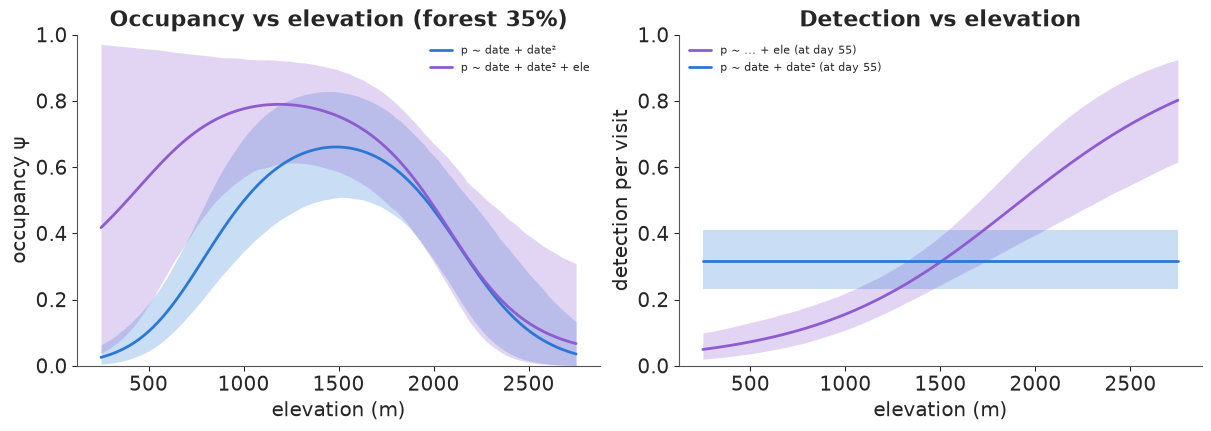

In [15]:
m_pe = fits_p["p ~ date + date² + ele"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for lab, c in [("p ~ date + date²", BLUE), ("p ~ date + date² + ele", PURPLE)]:
    a0_, a_ = draws(fits_p[lab], "a0"), draws(fits_p[lab], "a")
    band(axes[0], ele_grid, expit(a0_[:, None] + a_[:, [0]] * eg + a_[:, [1]] * eg**2), c, lab)
axes[0].set(xlabel="elevation (m)", ylabel="occupancy ψ", ylim=(0, 1), title="Occupancy vs elevation (forest 35%)")
axes[0].legend(fontsize=8)
b0_, b_ = draws(m_pe, "b0"), draws(m_pe, "b")
band(axes[1], ele_grid, expit(b0_[:, None] + b_[:, [2]] * eg), PURPLE, "p ~ ... + ele (at day 55)")
b0_, b_ = draws(idata_occ, "b0"), draws(idata_occ, "b")
band(axes[1], ele_grid, expit(b0_[:, None] + 0 * eg), BLUE, "p ~ date + date² (at day 55)")
axes[1].set(xlabel="elevation (m)", ylabel="detection per visit", ylim=(0, 1),
            title="Detection vs elevation")
axes[1].legend(fontsize=8);

LOO prefers adding elevation to the detection model (by about 7 elpd, dse 4) and both beat a
constant $p$. Detection rises steeply with elevation (slope 1.1 per 600 m, 94% HDI 0.6-1.6) -
from about 0.05 per visit at 250 m to about 0.8 at 2750 m. That is plausible - in the lowlands
crossbills are sparse, and fewer birds means fewer chances to detect one (abundance-induced
heterogeneity, the idea behind the Royle-Nichols model) - and it is one candidate explanation
for the excess of 111 histories.

But look at what it does to occupancy. If detection at 500 m is below 0.1 per visit,
three visits find an occupied lowland quadrat less than one time in four, so the few lowland
detections are compatible with *many* occupied lowland quadrats - and the occupancy curve at
low elevation becomes nearly uninformative (0.05-0.97 at 250 m), pushing mean occupancy from
0.39 to 0.58. Nothing in the data pins this down: $p$ at low elevation is an extrapolation of a
logit-linear curve fitted where the birds were actually found. This is the central difficulty
of occupancy modelling: **when the same covariate enters $\psi$ and $p$, the model can trade
one against the other**, and LOO rewards the better fit to the histories we have, not the
better answer about histories we would need (repeated detections in the lowlands). The honest
report is both numbers and the reason they differ; the practical fix is design - more visits,
or more effort where detection is low.

## 6 · Nine seasons: the naive trend is partly a detection trend

Now the question every monitoring programme exists to answer: is the population changing?
We fit the occupancy model (both detection variants) to each of the nine seasons separately
and compare with the raw share of quadrats where the bird was found.

In [16]:
rows = []
for yy in YEARS:
    keep_, Y_, D_, S_ = season(yy)
    s_ = cb[keep_]
    ele_, forest_ = (s_.ele.to_numpy() - 1200) / 600, (s_.forest.to_numpy() - 35) / 28
    date_ = np.where(S_, (D_ - 55) / 20, 0.0)
    year = 1999 if yy == "99" else 2000 + int(yy)
    for lab, covs in [("date", ("date", "date²")), ("date+ele", ("date", "date²", "ele"))]:
        m_ = occupancy_model(Y_, S_, ele_, forest_, date_, p_covs=covs)
        id_ = fit(m_, f"{year}, p ~ {lab}")
        pb = draws(id_, "psi").mean(1)
        b0_, b_ = draws(id_, "b0", 1000), draws(id_, "b", 1000)
        X_ = np.stack([{"date": date_, "date²": date_**2, "ele": ele_[:, None] + 0 * date_}[c] for c in covs], -1)
        p_vis = expit(b0_[:, None, None] + np.einsum("svk,dk->dsv", X_, b_))[:, S_]   # p on the visits made
        rows.append({"year": year, "p model": lab, "naive": (Y_.sum(1) > 0).mean(), "psi_mean": pb.mean(),
                     "psi_lo": np.quantile(pb, 0.055), "psi_hi": np.quantile(pb, 0.945),
                     "p_mean": p_vis.mean(), "p_lo": np.quantile(p_vis.mean(1), 0.055),
                     "p_hi": np.quantile(p_vis.mean(1), 0.945)})
        del id_
years = pd.DataFrame(rows)
years.pivot(index="year", columns="p model", values=["naive", "psi_mean", "p_mean"]).round(3)

  1999, p ~ date                 1.2 s | divergences 0 | max r_hat 1.002 | min ESS 1309


  1999, p ~ date+ele             1.5 s | divergences 0 | max r_hat 1.003 | min ESS 1765


  2000, p ~ date                 1.1 s | divergences 0 | max r_hat 1.004 | min ESS 1886


  2000, p ~ date+ele             1.3 s | divergences 0 | max r_hat 1.002 | min ESS 2269


  2001, p ~ date                 1.1 s | divergences 0 | max r_hat 1.002 | min ESS 1922


...

  2006, p ~ date                 1.2 s | divergences 0 | max r_hat 1.001 | min ESS 1862


  2006, p ~ date+ele             1.4 s | divergences 0 | max r_hat 1.004 | min ESS 1540


  2007, p ~ date                 1.2 s | divergences 0 | max r_hat 1.003 | min ESS 2020


  2007, p ~ date+ele             1.1 s | divergences 0 | max r_hat 1.002 | min ESS 1975


naive          psi_mean          p_mean         
p model   date date+ele     date date+ele   date date+ele
year                                                     
1999     0.257    0.257    0.386    0.583  0.329    0.248
2000     0.347    0.347    0.368    0.385  0.641    0.551
2001     0.219    0.219    0.243    0.271  0.562    0.441
2002     0.324    0.324    0.379    0.398  0.518    0.481
2003     0.398    0.398    0.439    0.444  0.576    0.547
2004     0.311    0.311    0.345    0.365  0.574    0.510
2005     0.346    0.346    0.362    0.413  0.664    0.483
2006     0.265    0.265    0.355    0.571  0.396    0.289
2007     0.351    0.351    0.386    0.389  0.592    0.564

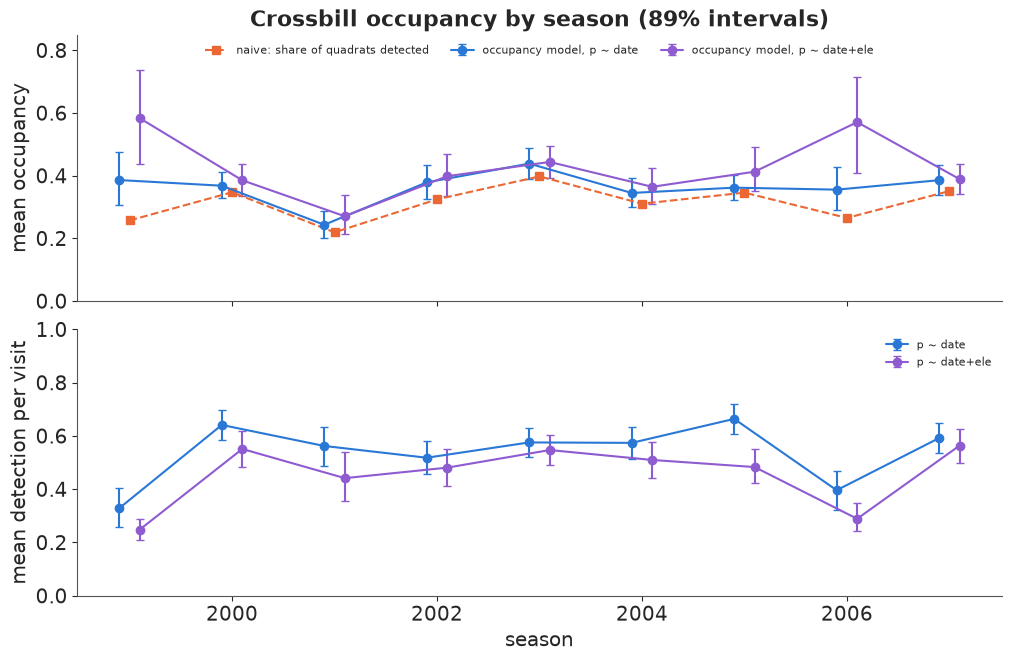

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
for (lab, c, dx) in [("date", BLUE, -0.1), ("date+ele", PURPLE, 0.1)]:
    d_ = years[years["p model"] == lab]
    axes[0].errorbar(d_.year + dx, d_.psi_mean, yerr=[d_.psi_mean - d_.psi_lo, d_.psi_hi - d_.psi_mean],
                     fmt="o-", color=c, capsize=3, label=f"occupancy model, p ~ {lab}")
    axes[1].errorbar(d_.year + dx, d_.p_mean, yerr=[d_.p_mean - d_.p_lo, d_.p_hi - d_.p_mean],
                     fmt="o-", color=c, capsize=3, label=f"p ~ {lab}")
d_ = years[years["p model"] == "date"]
axes[0].plot(d_.year, d_.naive, "s--", color=ORANGE, label="naive: share of quadrats detected")
axes[0].set(ylabel="mean occupancy", ylim=(0, 0.85), title="Crossbill occupancy by season (89% intervals)")
axes[0].legend(fontsize=8, ncol=3, loc="upper center")
axes[1].set(ylabel="mean detection per visit", xlabel="season", ylim=(0, 1))
axes[1].legend(fontsize=8);

In [18]:
d_ = years[years["p model"] == "date"]
print("correlation across seasons, naive vs mean detection p:", np.corrcoef(d_.naive, d_.p_mean)[0, 1].round(2))
print("correlation across seasons, occupancy (p ~ date) vs mean p:", np.corrcoef(d_.psi_mean, d_.p_mean)[0, 1].round(2))
print("range across seasons: naive", d_.naive.min().round(3), "-", d_.naive.max().round(3),
      "| occupancy (p ~ date)", d_.psi_mean.min().round(3), "-", d_.psi_mean.max().round(3))

correlation across seasons, naive vs mean detection p: 0.58
correlation across seasons, occupancy (p ~ date) vs mean p: -0.07
range across seasons: naive 0.219 - 0.398 | occupancy (p ~ date) 0.243 - 0.439


All 18 fits are clean. Three things stand out.

* **The naive series tracks detection.** Across seasons the naive share correlates with the
  mean detection probability ($r \approx 0.6$); the corrected occupancy (p ~ date) does not
  ($r \approx -0.1$). The naive dips in 1999 and 2006 coincide with the two seasons of poor
  detection (p about 0.33 and 0.40, against 0.5-0.65 otherwise); after correction those seasons
  look like their neighbours (0.36-0.39). An analyst reading the naive series would report a
  crash in 2006 and a recovery in 2007 that are mostly about how audible the birds were.
* **Some variation is real.** 2001 stays low under every model (about 0.24-0.27) in a season with
  ordinary detection, so fewer quadrats were probably occupied that year (crossbills are
  nomadic and follow the conifer cone crop, so irregular years are plausible).
* **The detection model matters most exactly when detection is poor.** With elevation in $p$,
  1999 and 2006 jump to about 0.58 and 0.57 with wide intervals - the section-5 extrapolation
  again - while in good-detection years the two variants agree within their intervals.

## 7 · When detection and occupancy are confounded

The occupancy model is identified *only* because the visits are repeated: the pattern of
1s and 0s *within* a detected quadrat tells us $p$, and $p$ then tells us how many all-zero
quadrats are hiding a bird. With a single visit, the data are Bernoulli($\psi_i\, p_i$)
and only the product is informed - any split between $\psi$ and $p$ fits equally well. So
with few visits (or a small $p$, where repeat detections are rare) the prior on detection
decides the answer. We refit 1999 using only the first visit, the first two, and all three,
under three priors on the detection intercept: the default Normal(0, 1.5), a confident
"detection is hard" prior Normal(-2, 0.5) (p about 0.12 at day 55) and a confident "detection
is easy" prior Normal(1, 0.5) (p about 0.73).

In [19]:
PRIORS = {"default N(0, 1.5)": (0.0, 1.5), "'hard' N(-2, 0.5)": (-2.0, 0.5), "'easy' N(1, 0.5)": (1.0, 0.5)}
rows = []
for n_vis in (1, 2, 3):
    S_k = S.copy()
    S_k[:, n_vis:] = False
    ok = S_k.any(1)
    for plab, pr in PRIORS.items():
        m_ = occupancy_model(Y[ok] * S_k[ok], S_k[ok], ELE[ok], FOREST[ok], np.where(S_k, DATE, 0)[ok], b0_prior=pr)
        id_ = fit(m_, f"{n_vis} visit(s), {plab}")
        pb = draws(id_, "psi").mean(1)
        rows.append({"visits": n_vis, "prior": plab, "mean": pb.mean(), "lo": np.quantile(pb, 0.055),
                     "hi": np.quantile(pb, 0.945), "p_day55": expit(draws(id_, "b0")).mean()})
        del id_
conf = pd.DataFrame(rows)
conf.round(3)

  1 visit(s), default N(0, 1.5)   1.5 s | divergences 0 | max r_hat 1.004 | min ESS 864


  1 visit(s), 'hard' N(-2, 0.5)   1.5 s | divergences 0 | max r_hat 1.004 | min ESS 1653


  1 visit(s), 'easy' N(1, 0.5)   1.3 s | divergences 0 | max r_hat 1.002 | min ESS 1953


  2 visit(s), default N(0, 1.5)   1.2 s | divergences 0 | max r_hat 1.004 | min ESS 1043


  2 visit(s), 'hard' N(-2, 0.5)   1.4 s | divergences 0 | max r_hat 1.004 | min ESS 1610


  2 visit(s), 'easy' N(1, 0.5)   1.1 s | divergences 0 | max r_hat 1.003 | min ESS 1715


  3 visit(s), default N(0, 1.5)   1.2 s | divergences 0 | max r_hat 1.002 | min ESS 1309


  3 visit(s), 'hard' N(-2, 0.5)   1.4 s | divergences 0 | max r_hat 1.003 | min ESS 1371


  3 visit(s), 'easy' N(1, 0.5)   1.1 s | divergences 0 | max r_hat 1.001 | min ESS 1925


,visits,prior,mean,lo,hi,p_day55
0,1,"default N(0, 1.5)",0.320,0.109,0.631,0.497
1,1,"'hard' N(-2, 0.5)",0.550,0.333,0.805,0.209
2,1,"'easy' N(1, 0.5)",0.179,0.102,0.308,0.703
3,2,"default N(0, 1.5)",0.366,0.247,0.506,0.336
4,2,"'hard' N(-2, 0.5)",0.445,0.330,0.559,0.235
5,2,"'easy' N(1, 0.5)",0.272,0.203,0.357,0.513
6,3,"default N(0, 1.5)",0.386,0.307,0.477,0.316
7,3,"'hard' N(-2, 0.5)",0.423,0.338,0.516,0.262
8,3,"'easy' N(1, 0.5)",0.345,0.283,0.417,0.395


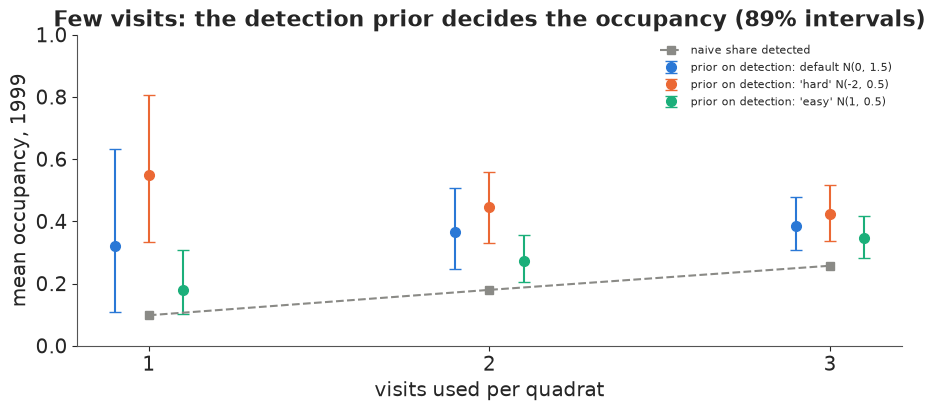

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
for k, (plab, c) in enumerate(zip(PRIORS, [BLUE, ORANGE, AQUA])):
    d_ = conf[conf.prior == plab]
    ax.errorbar(d_.visits + (k - 1) * 0.1, d_["mean"], yerr=[d_["mean"] - d_.lo, d_.hi - d_["mean"]],
                fmt="o", color=c, capsize=4, ms=7, label=f"prior on detection: {plab}")
naive_by_k = [((Y * (np.arange(3) < k)).sum(1) > 0).mean() for k in (1, 2, 3)]
ax.plot([1, 2, 3], naive_by_k, "s--", color=GREY, label="naive share detected")
ax.set(xticks=[1, 2, 3], xlabel="visits used per quadrat", ylabel="mean occupancy, 1999", ylim=(0, 1),
       title="Few visits: the detection prior decides the occupancy (89% intervals)")
ax.legend(fontsize=8);

With **one visit**, the answer is whatever the detection prior says: the "hard" prior gives
mean occupancy 0.55, the "easy" one 0.18, and the default prior a wide 0.11-0.63. The posterior
for detection at day 55 barely moves from each prior (0.50, 0.21 and 0.70 against prior centres
0.50, 0.12 and 0.73). It does move a little, because $\psi$ and $p$ depend on *different*
covariates (elevation vs date) through fixed logit-linear forms - identification "by
functional form", which is real but fragile (Lele, Moreno & Bayne 2012 argued for it; others
have shown how much it rests on the link function being right). With **two visits** the three
answers move closer (0.27-0.45) and with **three** they are 0.35-0.42 - still visibly prior-
dependent in 1999, because with $p \approx 0.3$ quadrats with repeated detections are few, and
those are what separate $p$ from $\psi$. When you have to plan a survey, this plot is the
argument for visiting fewer sites more often; `az.psense` would give a formal
prior-sensitivity diagnostic along the same lines.

## Part B · How many mallards? The N-mixture model

## 8 · Data: three counts on 239 routes

Occupancy asks "is it there?". For abundant species the survey records *counts*, and the
question becomes "how many are there?". Kéry, Royle & Schmid (2005) used the 2002 Swiss survey
counts of mallards: each of 239 routes was walked up to three times and every mallard seen or
heard was counted. The site covariates (elevation, route length, forest cover) and the survey
covariates (survey intensity `ivel`, in minutes per km, and date) come already standardised
from the source.

In [21]:
data.describe("mallard")
mal = read_rdata(data.path("mallard"))
C_raw = mal["mallard.y"].reshape(3, -1).T                         # R stores matrices column by column
ivel_raw = np.asarray(mal["mallard.obs"]["ivel"]).reshape(3, -1).T
date_raw = np.asarray(mal["mallard.obs"]["date"]).reshape(3, -1).T
S_m = ~np.isnan(C_raw) & ~np.isnan(ivel_raw) & ~np.isnan(date_raw)
keep_m = S_m.any(1)
print(f"{keep_m.sum()} of {len(C_raw)} routes with at least one count; {(~S_m[keep_m]).sum()} missing counts")
C = np.where(S_m, C_raw, 0).astype(int)[keep_m]
S_m = S_m[keep_m]
IVEL, DATE_M = np.where(S_m, ivel_raw[keep_m], 0), np.where(S_m, date_raw[keep_m], 0)
X_lam = pd.DataFrame(mal["mallard.site"])[keep_m].to_numpy()
LAM_COVS = ["elev", "length", "forest"]
n_route = len(C)
print("count distribution:", dict(zip(*np.unique(C[S_m], return_counts=True))))
print(f"routes with any mallard: {(C.max(1) > 0).sum()};  sum over routes of the max count: {C.max(1).sum()}")

mallard: 239 sites x 3 repeated counts (mallard.y), site covariates elev, length (route), forest and survey covariates ivel (survey intensity), date - all covariates standardised by the source. Not a table: an R serialisation (gzip XDR) - parse data.path() (see E28).
  source: Kery, Royle & Schmid (2005, Ecol. Appl. 15:1450), mallard counts from the Swiss breeding bird survey (2002), as shipped with the R package `unmarked`.
  url:    https://raw.githubusercontent.com/cran/unmarked/master/data/mallard.RData
235 of 239 routes with at least one count; 46 missing counts
count distribution: {np.int64(0): np.int64(576), np.int64(1): np.int64(54), np.int64(2): np.int64(11), np.int64(3): np.int64(9), np.int64(4): np.int64(6), np.int64(7): np.int64(1), np.int64(10): np.int64(1), np.int64(12): np.int64(1)}
routes with any mallard: 40;  sum over routes of the max count: 75


Mostly zeros, a few ones and twos, and a tail up to 12. The **N-mixture model** (Royle 2004)
says route $i$ holds $N_i$ mallards, constant over the three visits (a closed population
within the season), and each is counted independently with probability $p_{ij}$:

$$N_i \sim \text{Poisson}(\lambda_i), \qquad C_{ij} \mid N_i \sim \text{Binomial}(N_i, p_{ij}),$$
$$\log \lambda_i = \alpha_0 + \alpha^\top x_i, \qquad \text{logit}\, p_{ij} = \beta_0 + \beta_1 \text{ivel}_{ij} + \beta_2 \text{date}_{ij} + \beta_3 \text{date}_{ij}^2 .$$

$N_i$ is unbounded, so the sum that marginalises it is truncated at a bound $K$:

$$P(C_{i\cdot}) = \sum_{N = \max_j C_{ij}}^{K} \text{Poisson}(N \mid \lambda_i) \prod_j \text{Binomial}(C_{ij} \mid N, p_{ij}).$$

$K$ must be large enough that the terms beyond it are negligible *for every route and every
plausible parameter value* - we check that after fitting instead of assuming it. The sum is a
(route x N x visit) array: 235 x 101 x 3 here, cheap. The negative-binomial variant replaces
the Poisson by NegBin($\lambda_i$, size $r$), which allows extra between-route variation in
abundance.

In [22]:
K = 100
N_GRID = np.arange(K + 1)


def nmix_logp_factory(kind):
    def logp(c, lam, p, mask, *extra):
        N = N_GRID[:, None]                                              # (N, 1) broadcast against visits
        cc = c[..., None, :]                                             # (..., 1, visit)
        pp, mm = p[..., None, :], mask[..., None, :]
        log_binom = (pt.gammaln(N + 1) - pt.gammaln(cc + 1) - pt.gammaln(pt.maximum(N - cc, 0) + 1)
                     + cc * pt.log(pp) + (N - cc) * pt.log1p(-pp))
        log_binom = pt.switch(pt.ge(N, cc), log_binom, -np.inf)          # N must be at least every count
        ll_counts = pt.sum(mm * log_binom, axis=-1)                     # (..., N)
        lam_ = lam[..., None]
        if kind == "Poisson":
            log_prior = N_GRID * pt.log(lam_) - lam_ - gammaln(N_GRID + 1)
        else:
            r = extra[0][..., None]
            log_prior = (pt.gammaln(N_GRID + r) - pt.gammaln(r) - gammaln(N_GRID + 1)
                         + r * pt.log(r / (r + lam_)) + N_GRID * pt.log(lam_ / (r + lam_)))
        return pt.logsumexp(log_prior + ll_counts, axis=-1)
    return logp


def nmix_random(lam, p, mask, *extra, rng=None, size=None):
    if extra:
        r = extra[0]
        N = rng.negative_binomial(r, r / (r + lam))
    else:
        N = rng.poisson(lam)
    return rng.binomial(N[..., None], p) * mask


def nmix_model(kind, name=""):
    coords = {"route": np.arange(n_route), "visit": [1, 2, 3], "lam_cov": LAM_COVS,
              "p_cov": ["ivel", "date", "date²"]}
    X_p = np.stack([IVEL, DATE_M, DATE_M**2], -1)
    with pm.Model(coords=coords, name=name) as m:
        a0 = pm.Normal("a0", 0.0, 2.0)
        a = pm.Normal("a", 0.0, 1.0, dims="lam_cov")
        b0 = pm.Normal("b0", 0.0, 1.5)
        b = pm.Normal("b", 0.0, 1.0, dims="p_cov")
        lam = pm.Deterministic("lam", pm.math.exp(a0 + X_lam @ a), dims="route")
        p = pm.Deterministic("p", pm.math.invlogit(b0 + pt.tensordot(X_p, b, axes=[[-1], [0]])), dims=("route", "visit"))
        params = [lam, p, S_m.astype(float)]
        sig = "(),(v),(v)->(v)"
        if kind == "NegBin":
            inv_r = pm.Exponential("inv_r", 1.0)             # 1/size: 0 = Poisson, larger = more overdispersion
            params.append(pt.broadcast_to(1.0 / inv_r, (n_route,)))
            sig = "(),(v),(v),()->(v)"
        pm.CustomDist("C", *params, logp=nmix_logp_factory(kind), random=nmix_random, signature=sig,
                      observed=C, dims=("route", "visit"))
    return m


nm_models = {k: nmix_model(k) for k in ["Poisson", "NegBin"]}
nm_fits = {k: fit(m_, f"N-mixture, {k}") for k, m_ in nm_models.items()}
az.summary(nm_fits["Poisson"], var_names=["a0", "a", "b0", "b"], ci_kind="hdi", ci_prob=0.94, round_to=2)

  N-mixture, Poisson             5.2 s | divergences 0 | max r_hat 1.003 | min ESS 1755


  N-mixture, NegBin              5.0 s | divergences 0 | max r_hat 1.002 | min ESS 2309


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a0,-1.94,0.23,-2.35,-1.50,1754.59,2250.74,1.0,0.01,0.0
a[elev],-1.43,0.23,-1.86,-1.01,1798.19,1869.02,1.0,0.01,0.0
a[length],-0.39,0.13,-0.63,-0.15,4057.17,3282.32,1.0,0.00,0.0
a[forest],-0.71,0.16,-1.00,-0.41,3312.77,2822.68,1.0,0.00,0.0
b0,0.25,0.22,-0.16,0.68,3613.29,3105.55,1.0,0.00,0.0
b[ivel],0.29,0.17,-0.02,0.63,5400.43,2987.38,1.0,0.00,0.0
b[date],-0.38,0.15,-0.65,-0.08,2782.57,2834.27,1.0,0.00,0.0
b[date²],0.01,0.09,-0.15,0.16,2501.92,2782.00,1.0,0.00,0.0


In [23]:
az.summary(nm_fits["NegBin"], var_names=["a0", "a", "b0", "b", "inv_r"], ci_kind="hdi", ci_prob=0.94, round_to=2)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a0,-1.73,0.27,-2.24,-1.21,2309.22,2365.81,1.0,0.01,0.00
a[elev],-1.31,0.27,-1.83,-0.83,2397.47,1961.98,1.0,0.01,0.00
a[length],-0.17,0.21,-0.55,0.22,3429.40,3128.53,1.0,0.00,0.00
a[forest],-0.69,0.22,-1.09,-0.28,4914.12,2927.41,1.0,0.00,0.00
b0,-0.04,0.28,-0.56,0.50,3520.08,2926.22,1.0,0.00,0.00
b[ivel],0.18,0.21,-0.21,0.60,5480.88,3401.42,1.0,0.00,0.00
b[date],-0.32,0.14,-0.59,-0.05,2844.44,2862.65,1.0,0.00,0.00
b[date²],-0.00,0.08,-0.15,0.15,2560.17,2756.10,1.0,0.00,0.00
inv_r,2.04,0.68,0.82,3.29,4296.81,2698.57,1.0,0.01,0.01


Both fits are clean (no divergences, r_hat at most 1.003; each takes 12-16 s because the
likelihood sums over 101 values of $N$ for 235 routes and three visits). Mallards are
lowland birds: expected abundance falls steeply with elevation and with forest cover. A
counted mallard is detected with probability about 0.56 per visit at average conditions,
slightly higher with more survey effort (`ivel`) and lower later in the season.

The negative binomial finds strong overdispersion: $1/r \approx 2$ (94% HDI 0.8-3.3), far from
the Poisson value 0. Allowing it changes the *split*: the abundance intercept goes up (about
-1.7 vs -1.9), the detection intercept goes down (about 0.49 vs 0.56 at average conditions),
and the negative effect of route length disappears (it was propping up a Poisson that could
not otherwise produce a few very high counts).

### Is K = 100 enough? And what are the N's?

Given the parameters, the posterior of each $N_i$ is the normalised vector of terms inside the
sum - the same trick as $P(z_i = 1 \mid y)$ in part A, now over 101 values. Two things come out
of it: the probability mass sitting at the bound $K$ (which must be negligible), and draws of
every $N_i$, whose sum is the **number of mallards on the surveyed routes**.

In [24]:
def n_posterior(idata, kind, n=200, K_=K):
    """P(N_i = N | counts, parameters) for n posterior draws: array (draw, route, N)."""
    lam_d, p_d = draws(idata, "lam", n), draws(idata, "p", n)
    Ng = np.arange(K_ + 1)
    Nb, cb_ = Ng[None, None, :, None], C[None, :, None, :]
    lb = (gammaln(Nb + 1) - gammaln(cb_ + 1) - gammaln(np.maximum(Nb - cb_, 0) + 1)
          + cb_ * np.log(p_d[:, :, None, :]) + (Nb - cb_) * np.log1p(-p_d[:, :, None, :]))
    lb = np.where(Nb >= cb_, lb, -np.inf)
    ll = np.sum(np.where(S_m[None, :, None, :], lb, 0.0), axis=-1)
    lam_ = lam_d[..., None]
    if kind == "Poisson":
        lprior = Ng * np.log(lam_) - lam_ - gammaln(Ng + 1)
    else:
        r = 1 / draws(idata, "inv_r", n)[:, None, None]
        lprior = gammaln(Ng + r) - gammaln(r) - gammaln(Ng + 1) + r * np.log(r / (r + lam_)) + Ng * np.log(lam_ / (r + lam_))
    lj = lprior + ll
    return np.exp(lj - logsumexp(lj, axis=-1, keepdims=True))


N_post, N_tot = {}, {}
for kind, id_ in nm_fits.items():
    P = n_posterior(id_, kind)
    N_post[kind] = P
    cdf = P.cumsum(-1)
    N_draw = (rng.random(P.shape[:2] + (1,)) > cdf).sum(-1)              # one N_i per draw and route
    N_tot[kind] = N_draw.sum(1)
    tail = P[..., -10:].sum(-1)                                          # mass in the top 10 values of N
    print(f"{kind:8s} max over routes/draws of P(N in [91, 100] | data): {tail.max():.1e};  "
          f"mallards on the {n_route} routes: {N_tot[kind].mean():.0f}, 94% HDI {az.hdi(N_tot[kind], prob=0.94)}"
          f"  (sum of max counts {C.max(1).sum()})")

Poisson  max over routes/draws of P(N in [91, 100] | data): 7.3e-155;  mallards on the 235 routes: 86, 94% HDI [77. 96.]  (sum of max counts 75)
NegBin   max over routes/draws of P(N in [91, 100] | data): 2.4e-14;  mallards on the 235 routes: 101, 94% HDI [ 80. 128.]  (sum of max counts 75)


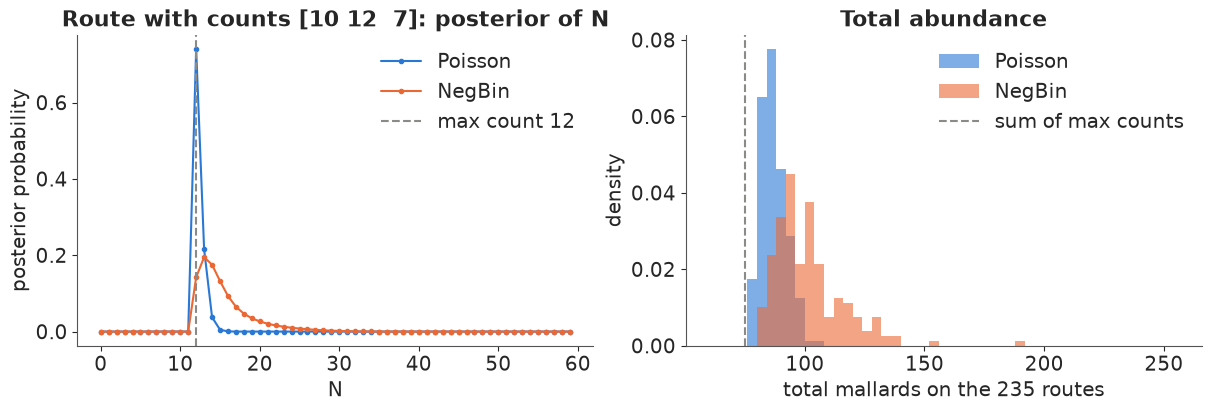

In [25]:
i_big = int(np.argmax(C.max(1)))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for kind, c in [("Poisson", BLUE), ("NegBin", ORANGE)]:
    axes[0].plot(N_GRID[:60], N_post[kind][:, i_big].mean(0)[:60], "o-", ms=3, color=c, label=kind)
    axes[1].hist(N_tot[kind], bins=np.arange(60, 260, 4), alpha=0.6, color=c, label=kind, density=True)
axes[0].axvline(C[i_big].max(), color=GREY, ls="--", label=f"max count {C[i_big].max()}")
axes[0].set(xlabel="N", ylabel="posterior probability", title=f"Route with counts {C[i_big]}: posterior of N")
axes[0].legend()
axes[1].axvline(C.max(1).sum(), color=GREY, ls="--", label="sum of max counts")
axes[1].set(xlabel="total mallards on the 235 routes", ylabel="density", title="Total abundance")
axes[1].legend();

The mass of the conditional posterior of $N$ in the ten values just below $K$ is at most about
$10^{-14}$ over every route and draw, so **K = 100 is ample**. (A heavier-tailed abundance
model is exactly where a small $K$ silently truncates the answer, so check it every time.) The route with counts 10, 12 and 7 shows the two models'
characters: the Poisson is sure there were 12-13 mallards; the negative binomial allows 20 or
30, because it believes some routes are crowded and detection is lower.

The totals differ accordingly: about **86 mallards (94% HDI 77-96) under the Poisson and 101
(80-128) under the negative binomial** on the 235 routes, against 75 if we add up each route's
maximum count - the naive abundance index, which again undershoots.

### The N-p trade-off

Counts identify the *product* $\lambda p$ directly (the mean count); they separate $\lambda$
from $p$ only through the **variation between the repeated counts** of the same route - the
binomial thinning of a fixed $N$ produces a specific pattern of agreement between visits. That
is a weak signal, and the posterior shows it: high abundance with low detection and low
abundance with high detection explain the mean counts equally well.

Poisson  corr(mean lambda, mean p) = -0.33;  implied mean count per visit 0.228 (sd 0.027; observed 0.237)
NegBin   corr(mean lambda, mean p) = -0.49;  implied mean count per visit 0.228 (sd 0.045; observed 0.237)


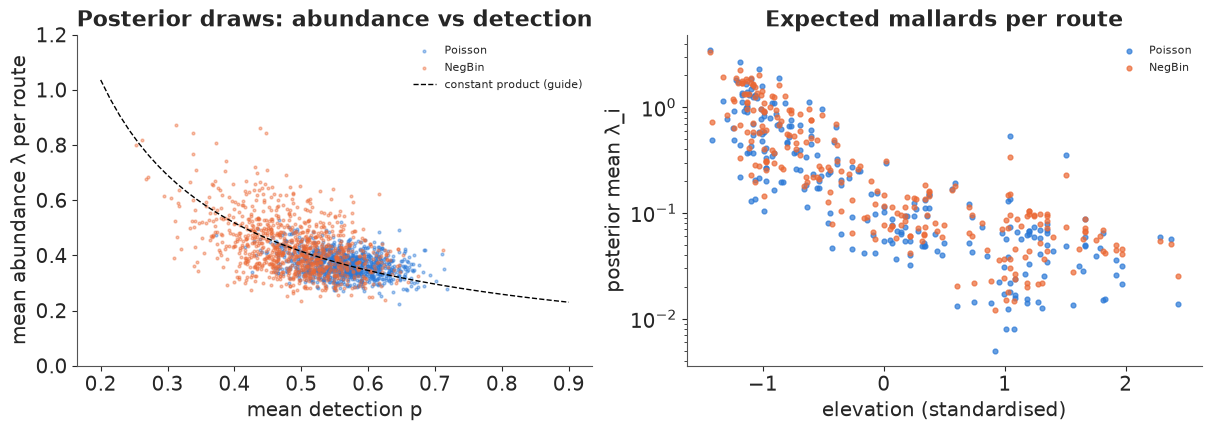

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for kind, c in [("Poisson", BLUE), ("NegBin", ORANGE)]:
    lam_m = draws(nm_fits[kind], "lam").mean(1)
    p_m = draws(nm_fits[kind], "p")[:, S_m].mean(1)
    axes[0].scatter(p_m[::4], lam_m[::4], s=4, alpha=0.4, color=c, label=kind)
    mean_count = (draws(nm_fits[kind], "lam")[:, :, None] * draws(nm_fits[kind], "p"))[:, S_m].mean(1)
    print(f"{kind:8s} corr(mean lambda, mean p) = {np.corrcoef(lam_m, p_m)[0, 1]:.2f};  "
          f"implied mean count per visit {mean_count.mean():.3f} (sd {mean_count.std():.3f}; observed "
          f"{C[S_m].mean():.3f})")
pp = np.linspace(0.2, 0.9, 50)
axes[0].plot(pp, np.mean(lam_m * p_m) / pp, "k--", lw=1, label="constant product (guide)")
axes[0].set(xlabel="mean detection p", ylabel="mean abundance λ per route", ylim=(0, 1.2),
            title="Posterior draws: abundance vs detection")
axes[0].legend(fontsize=8)
for kind, c in [("Poisson", BLUE), ("NegBin", ORANGE)]:
    lam_i = draws(nm_fits[kind], "lam").mean(0)
    axes[1].scatter(X_lam[:, 0], lam_i, s=12, color=c, alpha=0.7, label=kind)
axes[1].set(xlabel="elevation (standardised)", ylabel="posterior mean λ_i", yscale="log",
            title="Expected mallards per route")
axes[1].legend(fontsize=8);

The posterior draws spread along a curve of (roughly) constant $\bar\lambda \bar p$: more
mallards with lower detection or fewer with higher detection fit the counts about equally, and
the correlation is negative in both models - stronger for the negative binomial, whose extra
flexibility in abundance lets the draws slide further along the curve. The mean count itself
is pinned down; the split is not. With three counts per route and $p$ around 0.5 the
repeated counts still carry enough information to give a finite answer here, but this
trade-off is the reason N-mixture estimates of *absolute* abundance are fragile: Barker et al.
(2018, *Biometrics*) showed that without further assumptions the model cannot distinguish
between abundance heterogeneity and detection heterogeneity, and Dennis, Morgan & Ridout
(2015, *Biometrics*) that the negative binomial version can have an infinite abundance
estimate as a maximum-likelihood solution. The priors here (and a finite $K$) keep that
tail in check; the relative effects (elevation, forest) are much more robust than the totals.

### Checking and comparing: Poisson or negative binomial?

The posterior predictive check compares the **distribution of counts** (how many zeros, ones,
..., and the largest count), and site-level LOO compares the two abundance distributions on
the same data - each route's three counts are left out together.

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Poisson  P(max count >= observed 12) = 0.00;  predicted zeros 549 [517, 577] (observed 576)


NegBin   P(max count >= observed 12) = 0.12;  predicted zeros 571 [539, 600] (observed 576)
Poisson  routes with Pareto k > 0.7: [(24, [10, 12, 7])]
NegBin   routes with Pareto k > 0.7: [(24, [10, 12, 7])]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
NegBin,0,0.0,0.0,NaN,,1 k̂ > 0.70,11.2,-240.4,32.2,0.8
Poisson,1,-19.3,12.1,0.9,,1 k̂ > 0.70,14.9,-259.7,38.8,0.2


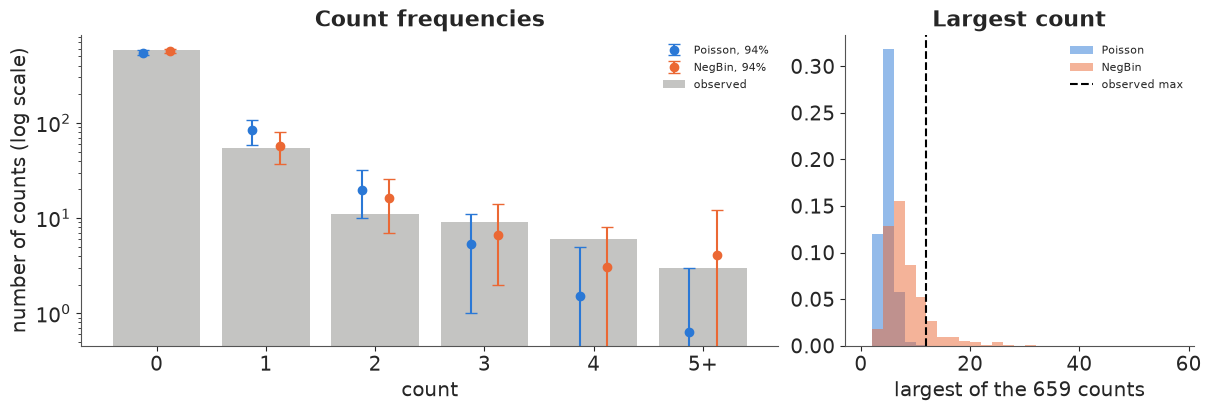

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1]})
cats = [0, 1, 2, 3, 4, 5]
obs_cnt = [np.sum(C[S_m] == k) if k < 5 else np.sum(C[S_m] >= 5) for k in cats]
loos_m = {}
for j, (kind, c) in enumerate([("Poisson", BLUE), ("NegBin", ORANGE)]):
    with nm_models[kind]:
        ppc_ = pm.sample_posterior_predictive(nm_fits[kind].isel(draw=slice(None, None, 4)),
                                              random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(nm_fits[kind], progressbar=False)
    loos_m[kind] = az.loo(nm_fits[kind])
    cr = ppc_.posterior_predictive["C"].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()[:, S_m]
    rep = np.stack([(cr == k).sum(1) if k < 5 else (cr >= 5).sum(1) for k in cats], 1)
    lo, hi = np.quantile(rep, [0.03, 0.97], axis=0)
    x = np.arange(len(cats)) + (j - 0.5) * 0.25
    axes[0].errorbar(x, rep.mean(0), yerr=[rep.mean(0) - lo, hi - rep.mean(0)], fmt="o", color=c, capsize=4,
                     label=f"{kind}, 94%")
    axes[1].hist(cr.max(1), bins=np.arange(0, 60, 2), color=c, alpha=0.5, density=True, label=kind)
    print(f"{kind:8s} P(max count >= observed {C.max()}) = {(cr.max(1) >= C.max()).mean():.2f};  "
          f"predicted zeros {rep[:, 0].mean():.0f} [{lo[0]:.0f}, {hi[0]:.0f}] (observed {obs_cnt[0]})")
axes[0].bar(np.arange(len(cats)), obs_cnt, color=GREY, alpha=0.5, label="observed")
axes[0].set_yscale("log")
axes[0].set_xticks(range(len(cats)), ["0", "1", "2", "3", "4", "5+"])
axes[0].set(xlabel="count", ylabel="number of counts (log scale)", title="Count frequencies")
axes[0].legend(fontsize=8)
axes[1].axvline(C.max(), color="k", ls="--", label="observed max")
axes[1].set(xlabel=f"largest of the {S_m.sum()} counts", title="Largest count")
axes[1].legend(fontsize=8)
for kind, l_ in loos_m.items():
    bad = np.flatnonzero(l_.pareto_k.to_numpy() > 0.7)
    print(f"{kind:8s} routes with Pareto k > 0.7: {[(int(i), C[i].tolist()) for i in bad]}")
    l_.log_weights = None
az.compare(loos_m, round_to=1)

The Poisson N-mixture model cannot produce the tail: it predicts more ones than were
observed, far too few counts of 4 or more, and a largest count of 12 or more essentially never
(probability 0.00); it also sits at the edge of its interval for the number of zeros. The
negative binomial reproduces the whole count distribution, gives the observed maximum a
probability of about 0.1, and wins on route-level LOO by about 19 elpd (dse 12). In both models
one route gets Pareto $k > 0.7$ - the route with counts 10, 12 and 7, which on its own pulls
the fit of the tail - so for a final comparison it should be refitted without that route
(`az.reloo`) or checked with K-fold CV. The PPC already tells the same story.

So the model that fits better is also the one with the *larger and less certain* total. That
is the honest summary of N-mixture modelling: the count distribution (Poisson, negative
binomial, zero-inflated...) is a modelling choice that the data only partly adjudicate, and
the absolute abundance moves with it.

## Part C · How many hares? Capture-recapture by data augmentation

## 9 · Data: 68 hares, 6 nights

Counting unmarked animals leans on the binomial-thinning assumption. **Capture-recapture**
gets the same information more directly: animals are caught, marked and released, so every
individual has its own detection history. The classic snowshoe hare study (Otis et al. 1978)
trapped on 6 consecutive nights and caught 68 different hares. The population is closed
(six nights), so the one unknown is $N$: how many hares were never caught?

In [28]:
data.describe("snowshoe_hare")
H = read_rdata(data.path("snowshoe_hare"))["hare"].reshape(6, -1).T      # (hare, night)
n_seen, T = H.shape
freq = np.bincount(H.sum(1), minlength=T + 1)[1:]
print(f"{n_seen} hares, {T} nights; caught per night: {H.sum(0)}")
print("capture frequencies f_k (hares caught exactly k times):", dict(zip(range(1, T + 1), freq)))

snowshoe_hare: Capture histories of 68 hares over 6 trapping occasions (a 68 x 6 0/1 matrix stored column by column). Not a table: an R serialisation (gzip XDR) - parse data.path() (see E28).
  source: Snowshoe hare live-trapping (Otis, Burnham, White & Anderson 1978, Wildlife Monographs 62; Cormack 1989, Biometrics 45:395), via the R package `Rcapture` (Baillargeon & Rivest 2007).
  url:    https://raw.githubusercontent.com/cran/Rcapture/master/data/hare.rda
68 hares, 6 nights; caught per night: [16 28 20 26 23 32]
capture frequencies f_k (hares caught exactly k times): {1: np.int64(25), 2: np.int64(22), 3: np.int64(13), 4: np.int64(5), 5: np.int64(1), 6: np.int64(2)}


**Data augmentation** (Royle, Dorazio & Link 2007) turns "unknown $N$" into an occupancy
problem. Pad the 68 observed histories with $M - 68$ all-zero rows, to a total $M$ well above
any plausible $N$ (here $M = 400$). Each row $i$ gets an inclusion indicator $w_i \sim$
Bernoulli($\omega$) - "is this a real member of the population?" - and $N = \sum_i w_i$.
Then

$$P(y_{i\cdot}) = \omega\, P(y_{i\cdot} \mid \text{real}) + (1 - \omega)\, \mathbb{1}[y_{i\cdot} = 0],$$

which is *exactly* the occupancy likelihood of part A with $\omega$ in place of $\psi$ and
"hare" in place of "quadrat". A Uniform prior on $\omega$ makes the prior on $N$ uniform
on $0, \dots, M$. The detection sub-models are the classic trio:

* $M_0$: one capture probability $p$;
* $M_t$: a different $p_t$ each night (weather, bait);
* $M_h$: **individual heterogeneity** - each hare has its own $p_i$, with $\text{logit}\, p_i
  \sim \text{Normal}(\mu, \sigma)$ (a logit-normal $M_h$), or with $p_i$ one of two values
  (a two-class finite mixture, Pledger 2000).

For $M_h$ the individual effect is a second latent quantity to integrate out; with 400 rows
we do it by 30-point Gauss-Hermite quadrature rather than sampling 400 random effects, so
NUTS sees 2-4 parameters in every model. After fitting, $N$ is recovered like the finite-sample
occupancy: $N = 68 + \sum_{\text{unseen rows}} w_i$, with $P(w_i = 1 \mid y_i = 0)$ from Bayes'
rule.

In [29]:
M_AUG = 400
Y_aug = np.vstack([H, np.zeros((M_AUG - n_seen, T), int)])
k_aug = Y_aug.sum(1)                                   # captures per row
seen = k_aug > 0
GH_X, GH_W = np.polynomial.hermite_e.hermegauss(30)    # nodes/weights for a standard normal
GH_W = GH_W / GH_W.sum()


def cr_model(kind):
    with pm.Model() as m:
        omega = pm.Uniform("omega", 0.0, 1.0)
        if kind in ("M0", "Mt"):
            p = pm.Beta("p", 1.0, 1.0, shape=1 if kind == "M0" else T)
            ll_real = pt.sum(Y_aug * pt.log(p) + (1 - Y_aug) * pt.log1p(-p), axis=1)
        else:
            if kind == "Mh (logit-normal)":
                mu = pm.Normal("mu", 0.0, 1.5)
                sigma = pm.HalfNormal("sigma", 1.5)
                p_nodes, log_w = pm.math.invlogit(mu + sigma * GH_X), np.log(GH_W)
            else:                                           # two-class mixture, classes ordered by p
                lp = pm.Normal("logit_p", [-1.0, 1.0], 1.5, transform=pm.distributions.transforms.ordered)
                pi = pm.Beta("pi_low", 1.0, 1.0)
                p_nodes, log_w = pm.math.invlogit(lp), pt.stack([pt.log(pi), pt.log1p(-pi)])
            pm.Deterministic("p_mean", pt.sum(pt.exp(log_w) * p_nodes))
            ll_k = k_aug[:, None] * pt.log(p_nodes) + (T - k_aug[:, None]) * pt.log1p(-p_nodes)
            ll_real = pt.logsumexp(ll_k + log_w, axis=1)   # history only enters through k (binomial kernel)
        ll = pt.switch(seen, pt.log(omega) + ll_real, pt.logaddexp(pt.log(omega) + ll_real, pt.log1p(-omega)))
        pm.Potential("likelihood", ll.sum())
        # P(real | never caught) for one all-zero row - the same for every padded row
        ll0 = ll_real[n_seen]
        pm.Deterministic("p_real_unseen", pt.exp(pt.log(omega) + ll0 - pt.logaddexp(pt.log(omega) + ll0, pt.log1p(-omega))))
    return m


cr_fits, N_hare = {}, {}
for kind in ["M0", "Mt", "Mh (logit-normal)", "Mh (2 classes)"]:
    kw = {"initvals": {"logit_p": np.array([-1.5, 0.5])}} if kind == "Mh (2 classes)" else {}
    cr_fits[kind] = fit(cr_model(kind), kind, target_accept=0.95, **kw)
    q0 = draws(cr_fits[kind], "p_real_unseen")
    N_hare[kind] = n_seen + rng.binomial(M_AUG - n_seen, q0)
    print(f"      N = {np.median(N_hare[kind]):.0f} (median), 94% HDI {az.hdi(N_hare[kind], prob=0.94)}, "
          f"P(N > 300) = {(N_hare[kind] > 300).mean():.3f}")

  M0                             0.7 s | divergences 0 | max r_hat 1.003 | min ESS 2350
      N = 75 (median), 94% HDI [69. 82.], P(N > 300) = 0.000


  Mt                             0.9 s | divergences 0 | max r_hat 1.002 | min ESS 5626
      N = 74 (median), 94% HDI [69. 80.], P(N > 300) = 0.000


  Mh (logit-normal)              2.2 s | divergences 0 | max r_hat 1.009 | min ESS 713
      N = 94 (median), 94% HDI [ 70. 135.], P(N > 300) = 0.000


  Mh (2 classes)                 1.3 s | divergences 0 | max r_hat 1.007 | min ESS 479
      N = 80 (median), 94% HDI [69. 96.], P(N > 300) = 0.000


In [30]:
pd.concat({k: az.summary(v, var_names=[x for x in v.posterior.data_vars if x != "p_real_unseen"],
                         round_to=2).iloc[:, :4] for k, v in cr_fits.items()})

mean    sd  eti89_lb  eti89_ub
M0                omega       0.19  0.02      0.16      0.22
                  p[0]        0.32  0.03      0.28      0.36
Mt                omega       0.19  0.02      0.16      0.22
                  p[0]        0.22  0.05      0.15      0.30
                  p[1]        0.38  0.06      0.29      0.47
                  p[2]        0.27  0.05      0.19      0.36
                  p[3]        0.35  0.05      0.27      0.44
                  p[4]        0.31  0.05      0.23      0.40
                  p[5]        0.43  0.06      0.34      0.53
Mh (logit-normal) mu         -1.34  0.43     -2.14     -0.80
                  omega       0.25  0.05      0.18      0.35
                  sigma       1.01  0.34      0.51      1.61
                  p_mean      0.25  0.05      0.17      0.33
Mh (2 classes)    omega       0.21  0.03      0.17      0.26
                  logit_p[0] -1.17  0.46     -2.13     -0.75
                  logit_p[1]  1.23  1.26     -0.49      3.44
                  pi_low      0.84  0.18      0.45      0.98
                  p_mean      0.30  0.04      0.24      0.36

All four fits are clean (no divergences, r_hat at most 1.01, the smallest ESS about 500 for the
two-class mixture, whose second class is poorly determined), and $P(N > 300) = 0$ everywhere,
so the augmentation bound $M = 400$ never constrains $N$. $M_0$ and $M_t$ agree: about **75
hares** (69-82), with a capture probability of about 0.3 per night that varies between nights
(0.22 on the first, 0.43 on the last) without changing $N$. The heterogeneity models are
higher and wider: the logit-normal $M_h$ gives a median of **94 (70-135)**, with a large
spread of individual catchability ($\sigma \approx 1$ on the logit scale), and the two-class
mixture **80 (69-96)**: most hares (about 84%) in a hard-to-catch class, a few in an
easy-to-catch one.

### Which detection model? The capture frequencies

The six capture frequencies $f_1, \dots, f_6$ (68 hares split by how often they were caught)
are the natural posterior predictive check for $M_0$ and $M_h$ - heterogeneity shows up as
too many hares caught once *and* too many caught (almost) every night, compared with a single
$p$. We simulate new trapping sessions from each posterior: draw $N$, give every animal its
$p_i$, trap six nights.

M0                 P(chi2(rep) >= chi2(obs)) = 0.15


Mt                 P(chi2(rep) >= chi2(obs)) = 0.11


Mh (logit-normal)  P(chi2(rep) >= chi2(obs)) = 0.86


Mh (2 classes)     P(chi2(rep) >= chi2(obs)) = 0.99


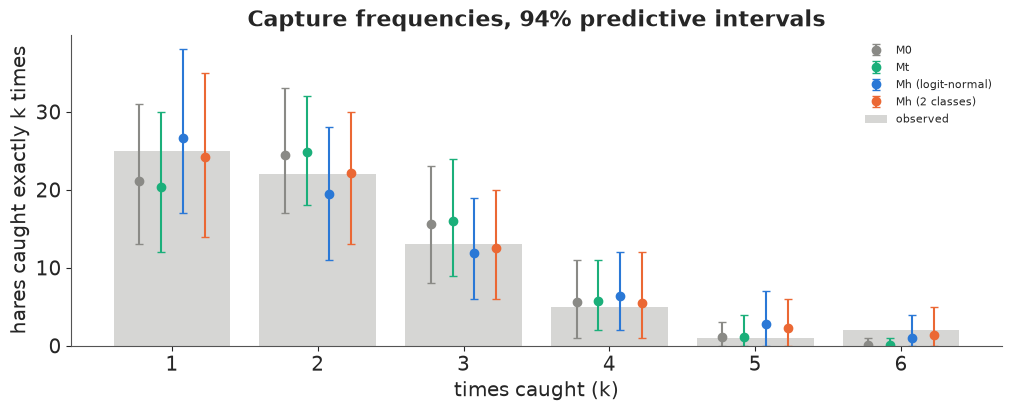

In [31]:
def replicate_freq(idata, kind, N_draws, n=1000):
    idx = np.linspace(0, len(N_draws) - 1, n).astype(int)
    out = np.zeros((n, T), int)
    for s, i in enumerate(idx):
        Ni = N_draws[i]
        if kind == "M0":
            p_i = np.full((Ni, T), draws(idata, "p")[i, 0])
        elif kind == "Mt":
            p_i = np.broadcast_to(draws(idata, "p")[i], (Ni, T))
        elif kind == "Mh (logit-normal)":
            p_i = expit(draws(idata, "mu")[i] + draws(idata, "sigma")[i] * rng.normal(size=(Ni, 1))) + 0 * np.ones(T)
        else:
            lp_, pi_ = draws(idata, "logit_p")[i], draws(idata, "pi_low")[i]
            p_i = expit(np.where(rng.random((Ni, 1)) < pi_, lp_[0], lp_[1])) + 0 * np.ones(T)
        k = (rng.random((Ni, T)) < p_i).sum(1)
        out[s] = np.bincount(k, minlength=T + 1)[1:]
    return out


fig, ax = plt.subplots(figsize=(10, 4))
for j, (kind, c) in enumerate(zip(cr_fits, [GREY, AQUA, BLUE, ORANGE])):
    rep = replicate_freq(cr_fits[kind], kind, N_hare[kind])
    lo, hi = np.quantile(rep, [0.03, 0.97], axis=0)
    x = np.arange(1, T + 1) + (j - 1.5) * 0.15
    ax.errorbar(x, rep.mean(0), yerr=[rep.mean(0) - lo, hi - rep.mean(0)], fmt="o", color=c, capsize=3, label=kind)
    chi = lambda f, e: np.sum((f - e) ** 2 / np.maximum(e, 0.5), axis=-1)          # a simple discrepancy
    print(f"{kind:18s} P(chi2(rep) >= chi2(obs)) = {np.mean(chi(rep, rep.mean(0)) >= chi(freq, rep.mean(0))):.2f}")
ax.bar(np.arange(1, T + 1), freq, color=GREY, alpha=0.35, label="observed")
ax.set(xlabel="times caught (k)", ylabel="hares caught exactly k times", title="Capture frequencies, 94% predictive intervals")
ax.legend(fontsize=8);

All four models cover most of the observed frequencies, but $M_0$ and $M_t$ cannot produce two
hares caught on all six nights (their 94% upper bound for $f_6$ is at most 1), and their
discrepancy $p$-values are lower (about 0.1-0.15) than those of the two heterogeneity models
(0.86 and 0.99). Night-to-night variation ($M_t$) does not help, because it affects every
hare equally: only individual differences produce both a surplus of singletons and a few
trap-happy regulars. The data favour heterogeneity - and that is where the trouble starts.

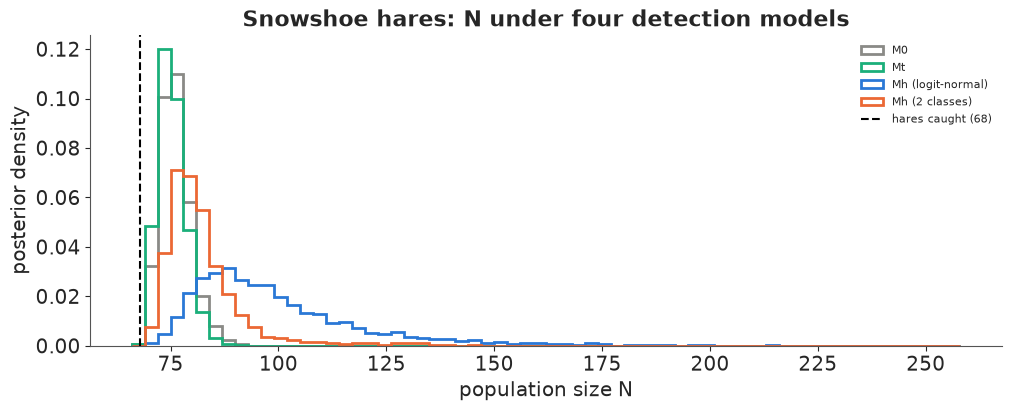

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.arange(66, 260, 3)
for kind, c in zip(cr_fits, [GREY, AQUA, BLUE, ORANGE]):
    ax.hist(N_hare[kind], bins=bins, density=True, histtype="step", lw=2, color=c, label=kind)
ax.axvline(n_seen, color="k", ls="--", label=f"hares caught ({n_seen})")
ax.set(xlabel="population size N", ylabel="posterior density", title="Snowshoe hares: N under four detection models")
ax.legend(fontsize=8);

Both heterogeneity models reproduce the capture frequencies essentially equally well, yet one
says "about 80, at most about 95" and the other "about 94, possibly 135". This is not a
sampling problem and more data of the same kind would not remove it. **Link (2003,
*Biometrics* 59:1123)** proved that under individual heterogeneity $N$ is not identifiable
without a parametric assumption: the hares that were never caught are those with $p_i$ near
0, and the observed frequencies say nothing about how much of the catchability distribution
sits near 0. The logit-normal has a long left tail of nearly uncatchable animals; the
two-class mixture does not - and that tail *is* the difference in $N$. (For reference, the
`Rcapture` documentation reports 81 for its preferred log-linear model, closer to our two-class
answer.) The Bayesian machinery does not rescue us from that; it just makes the dependence on
the heterogeneity model visible as posterior mass, which is the right thing to report.

A note on model comparison: LOO over the 400 augmented rows would leave out rows that are
not data, so for capture-recapture we compared the models by their predictions of the capture
frequencies instead.

## 10 · Summary

| Question | Model / display |
|---|---|
| Is the species at a site, given that we can miss it? | site occupancy: $z$ summed out in a `pm.CustomDist` (or `pymc_extras.marginalize`) |
| How much does ignoring detection cost? | naive vs occupancy: a third too low in 1999, fake year-to-year swings (sections 3, 6) |
| Which surveyed sites are occupied? | $P(z_i = 1 \mid y)$ by Bayes' rule on posterior draws; finite-sample totals (section 4) |
| Does the model fit? | detection-history frequencies; site-level LOO over whole histories (section 5) |
| When is occupancy not identified? | one visit, low $p$, shared covariates in $\psi$ and $p$: the prior or the functional form decides (sections 5, 7) |
| How many animals, from repeated counts? | N-mixture with $N$ summed to $K$ (check the mass near $K$); Poisson vs negative binomial (section 8) |
| How many animals, from marked individuals? | data augmentation = occupancy on padded rows; $M_0$, $M_t$, $M_h$ (section 9) |
| Can the data settle $N$ under heterogeneity? | no (Link 2003): two $M_h$ models, equal fit, different $N$ |

## Try it yourself

1. **Royle-Nichols.** Replace the occupancy model by the Royle-Nichols model: each quadrat has
   $N_i \sim$ Poisson($\lambda_i$) crossbills and a visit detects the species with probability
   $1 - (1 - r)^{N_i}$. Sum $N_i$ to a bound as in section 8. Does it explain the excess of 111
   histories, and what does it say about lowland occupancy $P(N_i > 0)$ compared with the two
   models of section 5?
2. **All seasons at once.** Fit the nine crossbill seasons jointly with a hierarchical year
   effect on occupancy and on detection (or a dynamic occupancy model with colonisation and
   extinction, MacKenzie et al. 2003, using the forward algorithm of E24 over $z_{it}$). How
   much does sharing information shrink the 1999 and 2006 intervals?
3. **Heterogeneity for the mallards.** Add a route-level random effect to detection in the
   N-mixture model (logit $p_{ij} = \ldots + \varepsilon_i$) and compare the total abundance
   and the $\lambda$-$p$ correlation with the negative binomial fit. Which one does route-level
   LOO prefer, and do they agree on $N$? Relate the answer to the Barker et al. (2018) result.